In [1]:
import os
import sys
import subprocess
import glob as glob
import shlex
from scipy.signal import medfilt
from scipy.special import wofz
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import seaborn as sb
import healpy
import numpy as np
import desispec.io
import fitsio
from pathlib import Path

os.environ["CUDA_VISIBLE_DEVICES"] = ""

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
from astropy.io import fits
import glob

sb.set_style('white')

# 1) Paths
DESISIM_REPO = "/pscratch/sd/m/mherbold/desisim"
DESISIM_PY   = f"{DESISIM_REPO}/py"
DESIMODEL_REPO = "/pscratch/sd/m/mherbold/desidatamodel/py/desimodeldata"
DESIMODEL_PY   = f"{DESIMODEL_REPO}/py"

# 2) Make sure Python can import desisim from your clone
os.environ["PYTHONPATH"] = DESISIM_PY + (":" + os.environ["PYTHONPATH"] if "PYTHONPATH" in os.environ else "")
if DESISIM_PY not in sys.path:
    sys.path.insert(0, DESISIM_PY)
os.environ["PYTHONPATH"] = DESIMODEL_PY + (":" + os.environ["PYTHONPATH"] if "PYTHONPATH" in os.environ else "")
if DESIMODEL_PY not in sys.path:
    sys.path.insert(0, DESIMODEL_PY)
    
# Optional but often needed by DESI stack:
# os.environ["DESIMODEL"] = "/path/to/desimodel"
# os.environ["DESI_ROOT"] = "/path/to/desi_root"

# Set device to GPU if available, else CPU
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")
device
# print(f"Using device: {device}")

print(torch.cuda.is_available())

False


In [2]:
%matplotlib inline

In [3]:
truth = fitsio.FITS('/pscratch/sd/m/mherbold/tests/metal_CNN_test/QQ_output_test/QQ_output_M-only-preproc/METAL_TEST_MgI-TEMP-1e5/truth-16-12.fits')
spec = fitsio.FITS('/pscratch/sd/m/mherbold/tests/metal_CNN_test/QQ_output_test/QQ_output_M-only-preproc/METAL_TEST_MgI-TEMP-1e5/spectra.fits')


In [4]:
# DR1 test
ifile = '/pscratch/sd/m/mherbold/tests/metal_CNN_test/QQ_output_test/transmission-16-1_2.fits'   # with z-mask

# full wavelength
outdir = '/pscratch/sd/m/mherbold/tests/metal_CNN_test/QQ_output_test/QQ_output_M-only-preproc/'

print(outdir) # Adjuts the path if this is not where you want to store the files produced by this tutorial 

/pscratch/sd/m/mherbold/tests/metal_CNN_test/QQ_output_test/QQ_output_M-only-preproc/


## CNN test

### Metal-line CNN for Lyman-alpha forest mocks (quickquasars)

This notebook (cell-marked `.py`, open with Jupytext or paste cells into Jupyter)
builds a small 1D CNN that detects the rest-frame wavelength (i.e. which known
metal transition) and strength (optical depth / EW-like amplitude) of metal
contaminant lines injected by `quickquasars` into Lya-forest mock spectra.

#### Design idea
`quickquasars` generates metal absorption from the *same* density skewer as
Lya, evaluated at the redshift implied by the metal's rest wavelength lambda_m
instead of 1215.67 A. In log10(lambda_obs) space this is a **constant**
additive shift:

    delta_m = log10(1215.67 / lambda_m)

independent of z_qso or z_absorber. That means the metal optical depth at a
given pixel is (a scaled, noisy version of) the Lya forest optical depth at a
*fixed* pixel offset elsewhere in the same spectrum. We exploit this by
feeding the CNN the raw flux *and* copies of the flux shifted by each known
delta_m as extra channels, turning "find a correlated echo far away in the
spectrum" into a local regression problem.

Adapt the TODO-marked I/O functions to your actual quickquasars output
(spectra-*.fits / truth-*.fits / transmission-*.fits paths and HDU names).

#### 1. Config: grid, transitions, pixel shifts

In [49]:

LYA_REST = 1215.67  # Angstrom

# Match this EXACTLY to the --metals list you passed to quickquasars.
METAL_LINES_FULL = {
    "SiII_1190": 1190.4158,
    "SiII_1193": 1193.2897,
    "SiIII_1207": 1206.500,
    "SiII_1260": 1206.500,
    "CIV_1548": 1548.2049,
    "CIV_1550": 1550.77845,
    'MgI(2853)': 2852.96,
}


# current test case: single contaminant, exaggerated strength, for pipeline validation
METAL_LINES = {
    # "SiII_1304": 1304.37,
    'MgI(2853)': 2852.96,
}
 
# FOREST_MIN = 1040.0   # rest-frame forest window (quasar rest frame), Angstrom
# FOREST_MAX = 1200.0   # keep clear of the Lya emission line proximity zone
FOREST_MIN = 1040.0   
FOREST_MAX = 3500.0 

N_PIX = 256
 
LOG_MIN = np.log10(FOREST_MIN)
LOG_MAX = np.log10(FOREST_MAX)
DLOGLAM = (LOG_MAX - LOG_MIN) / N_PIX
REST_GRID = 10 ** (LOG_MIN + (np.arange(N_PIX) + 0.5) * DLOGLAM)
 
 
def pixel_shift(lambda_m):
    """Constant pixel offset (in the fixed log-lambda grid) between a metal
    echo and the Lya-forest pattern it was copied from."""
    delta_loglam = np.log10(LYA_REST / lambda_m)
    return int(round(delta_loglam / DLOGLAM))

def shift_edge_padded(arr, shift, pad_value=1.0):
    """Shift an array without wrap-around, padding exposed pixels.

    Parameters
    ----------
    arr : array-like
        Input spectrum.
    shift : int
        Number of pixels to shift. Positive shifts toward larger pixel index.
    pad_value : float
        Value used to fill pixels exposed by the shift. For normalized flux,
        1.0 corresponds to no absorption.

    Returns
    -------
    shifted : ndarray
        Shifted, edge-padded array with the same length as arr.
    """
    arr = np.asarray(arr)
    shifted = np.full_like(arr, pad_value)

    if shift > 0:
        shifted[shift:] = arr[:-shift]
    elif shift < 0:
        shifted[:shift] = arr[-shift:]
    else:
        shifted[:] = arr

    return shifted
 
 
PIXEL_SHIFTS = {name: pixel_shift(w) for name, w in METAL_LINES.items()}
METAL_NAMES = list(METAL_LINES.keys())
N_METALS = len(METAL_NAMES)
print(PIXEL_SHIFTS)


{'MgI(2853)': -180}


#### 2. I/O — adapt to quickquasars outputs


In [50]:
base_path = '/pscratch/sd/m/mherbold/tests/metal_CNN_test/QQ_output_test/QQ_output_M-only-preproc'

uncontaminated = f'{base_path}/UNCONTAMINATED-1e5/spectra.fits'
contaminated = f'{base_path}/METAL_TEST_MgI-TEMP-1e5/spectra.fits'
# contaminated = f'{base_path}/METAL_TEST_MgI-TEMP-4/spectra.fits'

fitsio.FITS(contaminated)



  file: /pscratch/sd/m/mherbold/tests/metal_CNN_test/QQ_output_test/QQ_output_M-only-preproc/METAL_TEST_MgI-TEMP-1e5/spectra.fits
  mode: READONLY
  extnum hdutype         hduname[v]
  0      IMAGE_HDU       
  1      BINARY_TBL      FIBERMAP
  2      IMAGE_HDU       B_WAVELENGTH
  3      IMAGE_HDU       B_FLUX
  4      IMAGE_HDU       B_IVAR
  5      IMAGE_HDU       B_MASK
  6      IMAGE_HDU       R_WAVELENGTH
  7      IMAGE_HDU       R_FLUX
  8      IMAGE_HDU       R_IVAR
  9      IMAGE_HDU       R_MASK
  10     IMAGE_HDU       Z_WAVELENGTH
  11     IMAGE_HDU       Z_FLUX
  12     IMAGE_HDU       Z_IVAR
  13     IMAGE_HDU       Z_MASK

In [51]:

import desispec.io
import fitsio
 
TRUTH_FILENAME = "truth-16-12.fits" 
 
 
def read_arm_concat(spectra_path, targetid, spectra_obj=None):
    """
    Read+concatenate the B/R/Z arms for one TARGETID from a quickquasars
    spectra.fits file. Drops masked / non-positive-ivar pixels.
    Pass a pre-loaded `spectra_obj` (from desispec.io.read_spectra) to avoid
    re-reading the file for every target when looping over many TARGETIDs
    from the same file.
    """
    spectra = spectra_obj if spectra_obj is not None else desispec.io.read_spectra(spectra_path)
    tids = spectra.fibermap["TARGETID"]
    matches = np.where(np.asarray(tids) == targetid)[0]
    if len(matches) == 0:
        raise ValueError(f"TARGETID {targetid} not found in {spectra_path}")
    idx = matches[0]
 
    waves, fluxes, ivars = [], [], []
    for band in ["b", "r", "z"]:
        wave = spectra.wave[band]
        flux = spectra.flux[band][idx]
        ivar = spectra.ivar[band][idx]
        mask = spectra.mask[band][idx] if spectra.mask is not None else np.zeros_like(flux, dtype=int)
        good = (mask == 0) & (ivar > 0)
        waves.append(wave[good])
        fluxes.append(flux[good])
        ivars.append(ivar[good])
 
    wave_obs = np.concatenate(waves)
    flux = np.concatenate(fluxes)
    ivar = np.concatenate(ivars)
    order = np.argsort(wave_obs)
    # NOTE: b/r/z arms overlap slightly at their edges, so the concatenated
    # array isn't perfectly monotonic-unique there -- fine for interp1d used
    # below, but if you need a proper coadd in the overlap region later,
    # desispec has coaddition utilities for that.
    return wave_obs[order], flux[order], ivar[order]
 
 
def get_common_targetids(path_a, path_b):
    """TARGETIDs present in both the contaminated and uncontaminated files."""
    tid_a = fitsio.FITS(path_a)["FIBERMAP"].read(columns=["TARGETID"])["TARGETID"]
    tid_b = fitsio.FITS(path_b)["FIBERMAP"].read(columns=["TARGETID"])["TARGETID"]
    return np.intersect1d(tid_a, tid_b)
 
 
def read_arm_concat_raw(spectra_path, targetid, spectra_obj=None):
    """
    Like read_arm_concat, but does NOT drop masked pixels -- returns the FULL
    fixed instrument wavelength grid (same length/values for every target on
    the same instrument setup). Needed so that the contaminated and
    uncontaminated exposures of the same TARGETID line up pixel-for-pixel
    without any interpolation, which matters for the shared-continuum trick
    in build_paired_sample below.
    """
    spectra = spectra_obj if spectra_obj is not None else desispec.io.read_spectra(spectra_path)
    tids = spectra.fibermap["TARGETID"]
    matches = np.where(np.asarray(tids) == targetid)[0]
    if len(matches) == 0:
        raise ValueError(f"TARGETID {targetid} not found in {spectra_path}")
    idx = matches[0]
 
    waves, fluxes, ivars, masks = [], [], [], []
    for band in ["b", "r", "z"]:
        wave = spectra.wave[band]
        flux = spectra.flux[band][idx]
        ivar = spectra.ivar[band][idx]
        mask = spectra.mask[band][idx] if spectra.mask is not None else np.zeros_like(flux, dtype=int)
        waves.append(wave)
        fluxes.append(flux)
        ivars.append(ivar)
        masks.append(mask)
 
    wave_obs = np.concatenate(waves)
    flux = np.concatenate(fluxes)
    ivar = np.concatenate(ivars)
    mask = np.concatenate(masks)
    order = np.argsort(wave_obs)
    return wave_obs[order], flux[order], ivar[order], mask[order]
 
 
def read_ztrue(spectra_path, targetid):
    """Pull Z_true for this TARGETID from the companion truth file."""
    truth_path = os.path.join(os.path.dirname(spectra_path), TRUTH_FILENAME)
    truth = fitsio.FITS(truth_path)["TRUTH"].read(columns=["TARGETID", "Z"])
    row = truth[truth["TARGETID"] == targetid]
    if len(row) == 0:
        raise ValueError(f"TARGETID {targetid} not in truth file {truth_path}")
    return float(row["Z"][0])


def read_truth_data(truth_path, targetid):
    """
    Reads Z_true and TRUE_CONT (HDU 3) for a given TARGETID from the truth FITS file.
    Returns: (wave_cont, true_cont_flux, z_qso)
    """
    with fitsio.FITS(truth_path) as fx:
        # 1. Read Z from HDU 1 (TRUTH)
        truth_hdu = fx[1]
        tids = truth_hdu['TARGETID'][:]
        idx_truth = np.where(tids == targetid)[0]
        if len(idx_truth) == 0:
            raise ValueError(f"TARGETID {targetid} not found in HDU 1 of {truth_path}")
        z_qso = float(truth_hdu['Z'][idx_truth[0]])

        # 2. Read TRUE_CONT from HDU 3
        cont_hdu = fx[3]
        tids_cont = cont_hdu['TARGETID'][:]
        idx_cont = np.where(tids_cont == targetid)[0]
        if len(idx_cont) == 0:
            raise ValueError(f"TARGETID {targetid} not found in HDU 3 of {truth_path}")
        
        true_cont_flux = cont_hdu['TRUE_CONT'][idx_cont[0]].astype(np.float64)
        
        # 3. Reconstruct wavelength grid (using FITS header metadata if present)
        hdr = cont_hdu.read_header()
        if 'WAVE0' in hdr and 'DWAVE' in hdr:
            wave_cont = hdr['WAVE0'] + np.arange(len(true_cont_flux)) * hdr['DWAVE']
        elif 'CRVAL1' in hdr and 'CDELT1' in hdr:
            wave_cont = hdr['CRVAL1'] + np.arange(len(true_cont_flux)) * hdr['CDELT1']
        else:
            # Standard DESI quickquasars continuum grid (default step = 1.0 Å, adjust dwave to 2.0 Å if needed)
            dwave = 1.0
            wave_cont = np.arange(3600, 3600 + len(true_cont_flux) * dwave, dwave)

    return wave_cont, true_cont_flux, z_qso
 

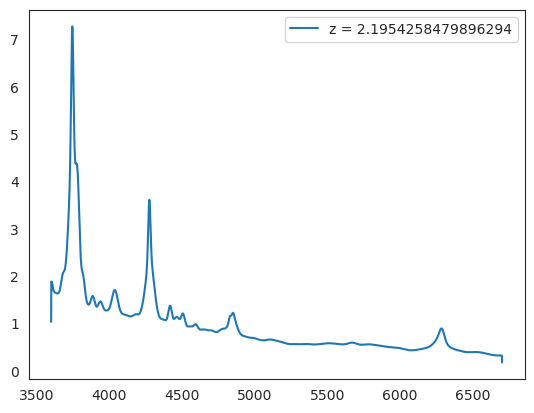

In [52]:
wave_cont_temp, true_cont_flux_temp, z_qso_temp = read_truth_data(
                                                    '/pscratch/sd/m/mherbold/tests/metal_CNN_test/QQ_output_test/QQ_output_M-only-preproc/METAL_TEST_MgI-TEMP-1e5/truth-16-12.fits', 
                                                    1005)

plt.plot(wave_cont_temp, true_cont_flux_temp, label=f'z = {z_qso_temp}')
plt.legend()
plt.show()

#### 3. Preprocessing: continuum normalize + resample to fixed rest-frame grid + add channels


In [53]:

def continuum_normalize(wave_obs, flux, ivar, z_qso, smooth_pix=150):
    """
    Superseded by the shared-continuum logic inside build_paired_sample --
    normalizing a single noisy exposure independently (as this function
    does) gives each exposure a DIFFERENT noisy continuum estimate, which
    then does NOT cancel in the flux_c/flux_u ratio and leaks noise/bias
    straight into the metal-line label. Left here only as a building block
    if you need to continuum-normalize a single spectrum outside the paired
    pipeline (e.g. for visualizing one exposure on its own).
    """
    from scipy.ndimage import median_filter
    cont = median_filter(flux, size=smooth_pix, mode="nearest")
    cont[cont <= 0] = np.nan
    norm_flux = flux / cont
    norm_ivar = ivar * cont ** 2
    return norm_flux, norm_ivar
 
 
def to_restframe_grid(wave_obs, flux, ivar, z_qso):
    """Resample onto the fixed N_PIX log-lambda grid in the quasar rest frame."""
    rest_wave = wave_obs / (1.0 + z_qso)
    sel = (rest_wave > FOREST_MIN) & (rest_wave < FOREST_MAX) & np.isfinite(flux)
    if sel.sum() < 10:
        return None
    f_interp = interp1d(rest_wave[sel], flux[sel], bounds_error=False, fill_value=1.0)
    iv_interp = interp1d(rest_wave[sel], ivar[sel], bounds_error=False, fill_value=0.0)
    flux_grid = f_interp(REST_GRID)
    ivar_grid = iv_interp(REST_GRID)
    return flux_grid, ivar_grid
 
 
def make_shifted_channels(flux_grid):
    """One extra input channel per metal transition: the forest pattern that
    would echo into that transition's absorption, aligned pixel-for-pixel."""
    channels = []
    for name in METAL_NAMES:
        shift = PIXEL_SHIFTS[name]
        shifted = np.roll(flux_grid, -shift)
        # pad the wrapped-around edge with continuum level (1.0) so it doesn't
        # masquerade as a real feature
        if shift > 0:
            shifted[-shift:] = 1.0
        elif shift < 0:
            shifted[:-shift] = 1.0
        channels.append(shifted)
    return np.stack(channels, axis=0)  # (N_METALS, N_PIX)
 

In [54]:
# add Lyman Alpha absorption channel

# LYA_REST = 1215.67
LYA_MIN = 1040.0
LYA_MAX = 1200.0

# binary lya channel (yes / no forest region)
def make_lya_binary_channel(rest_grid, lya_min=1040.0, lya_max=1200.0):
    """
    Binary mask indicating pixels in the Lyα forest rest-frame region.
    """
    return (
        (rest_grid >= lya_min) &
        (rest_grid <= lya_max)
    ).astype(np.float32)

# # continuous lya channel (apparent absorption / transmission in region)
# def make_lya_structure_channel(flux_grid, sigma_pix=1.0):
#     """
#     Smooth apparent optical-depth structure in the Lyα forest.

#     Outside the Lyα forest, set the channel to zero.
#     """

#     flux_safe = np.clip(flux_grid, 1e-3, None)

#     tau = -np.log(flux_safe)

#     tau_smooth = gaussian_filter1d(
#         tau,
#         sigma=sigma_pix,
#         mode="nearest",
#     )

#     lya_mask = (
#         (REST_GRID >= LYA_MIN) &
#         (REST_GRID <= LYA_MAX)
#     )

#     channel = np.zeros_like(flux_grid, dtype=np.float32)

#     channel[lya_mask] = tau_smooth[lya_mask]

#     return channel.astype(np.float32)

In [55]:
# # add metal absorption region mask

# def make_absorber_z_channel(z_qso, rest_grid, metal_wave):
#     z_abs = (
#         rest_grid * (1 + z_qso) / metal_wave
#     ) - 1.0

#     # Scale approximately to [-1, 1] over the useful range
#     return z_abs.astype(np.float32)

#### 4. Labels: per-pixel, per-transition metal optical depth


In [56]:

def build_paired_sample(targetid, uncontam_path, contam_path,
                         spectra_uncontam=None, spectra_contam=None,
                         cont_smooth_pix=150):
    """
    Build one training sample from the contaminated / uncontaminated spectra
    for a single TARGETID. Returns None if the forest window isn't covered.
 
    Continuum handling: rather than normalizing each exposure independently
    (which was giving a noisy continuum estimate on EACH side, and since the
    two estimates then differ, that noise doesn't cancel in the flux_c/flux_u
    ratio -- it leaks straight into the metal-line label as spurious
    scatter), we estimate ONE continuum from the average of both exposures
    (halves the noise going into the fit) and divide both sides by that SAME
    continuum. Any residual continuum-fit error or shape then cancels
    exactly in the ratio -- it only affects the overall normalization scale
    of the CNN input, not the label.
    """
    wave_u, flux_u, ivar_u, mask_u = read_arm_concat_raw(uncontam_path, targetid, spectra_uncontam)
    wave_c, flux_c, ivar_c, mask_c = read_arm_concat_raw(contam_path, targetid, spectra_contam)
    z_qso = read_ztrue(uncontam_path, targetid)
 
    if not np.array_equal(wave_u, wave_c):
        raise RuntimeError(
            f"wavelength grids differ between contaminated/uncontaminated "
            f"spectra for TARGETID {targetid} -- unexpected for the same "
            f"instrument setup/target; check that both files really share "
            f"the same fiber/exposure layout."
        )
    wave_obs = wave_u
 
    good = (mask_u == 0) & (mask_c == 0) & (ivar_u > 0) & (ivar_c > 0)
    if good.sum() < 20:
        return None
 
    from scipy.ndimage import median_filter
    avg_flux = 0.5 * (flux_u + flux_c)
    # fill masked/bad pixels for continuum-fitting purposes only, so the
    # median filter doesn't get corrupted by garbage values in masked gaps
    idx_good = np.where(good)[0]
    filled = np.interp(np.arange(len(avg_flux)), idx_good, avg_flux[idx_good])
    cont = median_filter(filled, size=cont_smooth_pix, mode="nearest")
    cont[cont <= 0] = np.nan
 
    flux_u_norm = flux_u / cont
    flux_c_norm = flux_c / cont
    ivar_u_norm = ivar_u * cont ** 2
    ivar_c_norm = ivar_c * cont ** 2
    ivar_u_norm[~good] = 0.0
    ivar_c_norm[~good] = 0.0
 
    grid_u = to_restframe_grid(wave_obs, flux_u_norm, ivar_u_norm, z_qso)
    grid_c = to_restframe_grid(wave_obs, flux_c_norm, ivar_c_norm, z_qso)
    if grid_u is None or grid_c is None:
        return None
    flux_u_grid, ivar_u_grid = grid_u
    flux_c_grid, ivar_c_grid = grid_c
 
    # network input is the *contaminated* (realistic) spectrum; label is the
    # metal-only optical depth recovered by differencing against the
    # metal-free twin. `weight` propagates BOTH exposures' noise (see
    # build_label_maps) since you only have one realization per side -- this
    # is what the training loss uses, not raw `ivar_c_grid`.
    label, weight = build_label_maps(flux_c_grid, flux_u_grid, ivar_c_grid, ivar_u_grid)
    return {
        "flux": flux_c_grid,
        "ivar": ivar_c_grid,
        "label": label,
        "weight": weight,
        "targetid": targetid,
        "z_qso": z_qso,
    }


# def build_paired_sample(targetid, contam_path, truth_path, spectra_contam=None):
#     """
#     Build one training sample using the contaminated spectrum paired with the 
#     noiseless TRUE_CONT baseline from the DESI truth file.
#     """
#     # 1. Read contaminated spectrum and truth data
#     wave_c, flux_c, ivar_c, mask_c = read_arm_concat_raw(contam_path, targetid, spectra_contam)
#     wave_cont, true_cont_flux, z_qso = read_truth_data(truth_path, targetid)

#     # 2. Interpolate TRUE_CONT onto observed contaminated wavelength grid
#     cont_obs = np.interp(wave_c, wave_cont, true_cont_flux)

#     # 3. Mask bad pixels and invalid/zero continuum values
#     good = (mask_c == 0) & (ivar_c > 0) & (cont_obs > 0)
#     if good.sum() < 20:
#         return None

#     # 4. Continuum normalization:
#     # Contaminated spectrum is normalized by TRUE_CONT
#     flux_c_norm = flux_c / cont_obs
#     ivar_c_norm = ivar_c * (cont_obs ** 2)
#     ivar_c_norm[~good] = 0.0

#     # Uncontaminated spectrum normalized by TRUE_CONT is identically 1.0 everywhere
#     flux_u_norm = np.ones_like(flux_c_norm)
#     ivar_u_norm = np.full_like(flux_c_norm, 1e10)  # High ivar (effectively noiseless baseline)

#     # 5. Interpolate onto standardized rest-frame grid
#     grid_c = to_restframe_grid(wave_c, flux_c_norm, ivar_c_norm, z_qso)
#     if grid_c is None:
#         return None
#     flux_c_grid, ivar_c_grid = grid_c

#     # Rest-frame reference continuum is 1.0 everywhere
#     flux_u_grid = np.ones_like(flux_c_grid)
#     ivar_u_grid = np.full_like(ivar_c_grid, 1e10)

#     # 6. Build linear flux deficit label: dF = 1.0 - flux_c_grid
#     label, weight = build_label_maps(flux_c_grid, flux_u_grid, ivar_c_grid, ivar_u_grid)

#     return {
#         "flux": flux_c_grid,
#         "ivar": ivar_c_grid,
#         "label": label,
#         "weight": weight,
#         "targetid": targetid,
#         "z_qso": z_qso,
#     }
 
 
def check_shared_noise_realization(targetid, uncontam_path, contam_path, n_show=5):
    """
    Diagnostic: if the two files DON'T share a noise realization (common for
    quickquasars -- the noise seed is often independent of the seed used for
    the density field / metal strengths / templates), the flux difference
    away from the metal feature will be consistent with the FULL per-pixel
    noise amplitude rather than ~0. If that's what you see, don't difference
    single pairs -- average many noise realizations first (see
    `build_averaged_pair_grids` below) before differencing.
    """
    wave_u, flux_u, ivar_u = read_arm_concat(uncontam_path, targetid)
    wave_c, flux_c, ivar_c = read_arm_concat(contam_path, targetid)
    z_qso = read_ztrue(uncontam_path, targetid)
 
    diff = flux_c - np.interp(wave_u, wave_u, flux_u)  # same grid check below is more robust
    rest = wave_u / (1 + z_qso)
    away = np.abs(rest - 1304.37) > 5  # Angstrom, away from the SiII(1304) feature
    std_diff = np.nanstd(diff[away])
    typical_noise = np.nanmedian(1 / np.sqrt(ivar_u[away]))
    print(f"TARGETID {targetid}: std(diff) away from line = {std_diff:.4f}, "
          f"typical 1/sqrt(ivar) = {typical_noise:.4f}, ratio = {std_diff/typical_noise:.2f}")
    print("  -> ratio near 0     : noise IS shared -- single-pair differencing is clean.")
    print("  -> ratio near 1.4   : noise is INDEPENDENT (sqrt(2) x single-exposure noise) -- average realizations.")
    return std_diff, typical_noise
 
 
def build_averaged_pair_grids(targetid, uncontam_paths, contam_paths):
    """
    NOT APPLICABLE to your current data (single realization per side) --
    kept here in case you're able to generate repeated noise draws of the
    same skewers later, which would let you build much cleaner labels than
    the single-pair-with-propagated-weights approach used below.
 
    uncontam_paths / contam_paths: lists of spectra.fits paths, each a
    DIFFERENT noise realization of the SAME underlying skewer/target (same
    density-field/metals/template seed, only the noise draw differs). Averages
    (ivar-weighted, i.e. inverse-variance stacked) the resampled flux across
    realizations separately for the contaminated and uncontaminated sets --
    this denoises each set toward its noiseless flux -- then differences the
    two *stacked* spectra for a much cleaner metal-only label than any single
    pair would give.
    """
    def stack(paths):
        num = np.zeros(N_PIX)
        den = np.zeros(N_PIX)
        z_qso = None
        for p in paths:
            wave, flux, ivar = read_arm_concat(p, targetid)
            if z_qso is None:
                z_qso = read_ztrue(p, targetid)
            fnorm, ivnorm = continuum_normalize(wave, flux, ivar, z_qso)
            grid = to_restframe_grid(wave, fnorm, ivnorm, z_qso)
            if grid is None:
                continue
            fg, ivg = grid
            ivg = np.nan_to_num(ivg, nan=0.0)
            fg = np.nan_to_num(fg, nan=1.0)
            num += fg * ivg
            den += ivg
        stacked_flux = np.divide(num, den, out=np.ones_like(num), where=den > 0)
        stacked_ivar = den
        return stacked_flux, stacked_ivar, z_qso
 
    flux_u, ivar_u, z_qso = stack(uncontam_paths)
    flux_c, ivar_c, _ = stack(contam_paths)
    label, weight = build_label_maps(flux_c, flux_u, ivar_c, ivar_u)
    return flux_c, ivar_c, label, weight, z_qso
 
 
def build_label_maps(flux_with, flux_without, ivar_with, ivar_without):
    """
    Returns (labels, weight) both shaped (N_METALS, N_PIX).
 
    labels: metal-only signal as a LINEAR flux difference,
        dF = flux_without - flux_with   (positive where metals add absorption)
    Deliberately NOT log optical depth (-log(flux_with/flux_without)): that
    involves a division and a log, both of which blow up whenever either
    exposure's flux noise-dips near zero -- routine at low S/N (e.g. camera
    edges near wmin/wmax, arm-overlap gaps). Those blow-ups show up as fixed-
    height "clipped ceiling" spikes at specific wavelengths that have nothing
    to do with real absorption and will swamp genuine, weak metal features.
    A linear difference has no such singularity -- it's just noisy where the
    data are noisy, which the `weight` map below already accounts for.
    For the weak realistic line strengths of interest (tau ~ 1e-4) and
    continuum-normalized flux ~1, dF ~= tau anyway, so this is an equally
    valid regression target, just numerically well-behaved. extract_lines'
    "strength" is accordingly an EW-like linear quantity now, not tau.
 
    weight: inverse-variance to use for the LOSS, not just IO's `ivar`. The
    label is a *difference* of two independently-noisy exposures, so its
    variance is the SUM of both exposures' variances:
        var(dF) ~ 1/ivar_with + 1/ivar_without
    Using only ivar_with here would understate how noisy the label really is
    by up to a factor of 2, and bias the network toward trusting noisy
    labels too much (this matters a lot with a single realization per side,
    per your setup -- there's no averaging-down of label noise otherwise).
    """
    dF_total = flux_without - flux_with

    good = (ivar_with > 0) & (ivar_without > 0)
    combined_ivar = np.zeros_like(ivar_with)
    combined_ivar[good] = 1.0 / (1.0 / ivar_with[good] + 1.0 / ivar_without[good])
    dF_total[~good] = 0.0

    labels = np.zeros((N_METALS, N_PIX), dtype=np.float32)
    weight = np.zeros((N_METALS, N_PIX), dtype=np.float32)
    
    for i in range(N_METALS):
        labels[i] = dF_total
        weight[i] = combined_ivar

    return labels, weight

#### 5. Dataset


In [57]:
# class MetalLineDataset(Dataset):
#     def __init__(self, samples):
#         """
#         samples: list of dicts, each with keys
#             'flux' (N_PIX,), 'ivar' (N_PIX,), 'label' (N_METALS, N_PIX)
#         """
#         self.samples = samples
 
#     def __len__(self):
#         return len(self.samples)
 
#     def __getitem__(self, idx):
#         s = self.samples[idx]
    
#         flux = s["flux"].astype(np.float32)
#         ivar = s["ivar"].astype(np.float32)
    
#         # Normalize inverse variance for use as a CNN input
#         IVAR_SCALE = 1e7
#         ivar = ivar / IVAR_SCALE    
#         # ivar = np.log1p(ivar)
#         # ivar = ivar / (np.mean(ivar) + 1e-8)
    
#         shifted = make_shifted_channels(flux).astype(np.float32)
    
#         x = np.concatenate(
#             [flux[None, :], ivar[None, :], shifted],
#             axis=0
#         )
    
#         y = s["label"].astype(np.float32)
#         w = s["weight"].astype(np.float32)
    
#         return torch.from_numpy(x), torch.from_numpy(y), torch.from_numpy(w)
 

In [58]:
def build_detection_targets(labels, min_peak=0.01, sigma_pix=1.5, distance=3):
    """
    Turn the continuous, sparse dF label (N_METALS, N_PIX) into a soft
    per-pixel detection heatmap (N_METALS, N_PIX) in [0, 1]: a small
    Gaussian bump centered on each true peak.

    A hard 0/1 target also works, but the soft Gaussian gives the
    classifier partial credit for being "close" during training, which
    speeds up convergence when peak positions only matter to within a
    few pixels (as they do here downstream in match_detections_v2).

    min_peak: same absolute threshold you already use elsewhere
        (extract_lines_v4 uses min_peak_tau=0.001-0.01) -- keep these
        consistent so "what counts as a real line" doesn't silently
        differ between label-building and evaluation.
    """

    n_metals, n_pix = labels.shape
    heatmap = np.zeros((n_metals, n_pix), dtype=np.float32)
    xs = np.arange(n_pix)

    for i in range(n_metals):
        tau = labels[i]
        if tau.max() < min_peak:
            continue
        peaks, _ = find_peaks(tau, height=min_peak, distance=distance)
        for p in peaks:
            heatmap[i] = np.maximum(
                heatmap[i],
                np.exp(-0.5 * ((xs - p) / sigma_pix) ** 2),
            )

    return heatmap

In [59]:
class MetalLineDatasetV2(Dataset):
    """
    Same as MetalLineDataset, but __getitem__ also returns the binary/soft
    detection target built from the true label, for the two-head model.
    """
    def __init__(self, samples, min_peak=0.01, sigma_pix=1.0):
                 # sigma_pix=1.5):
        
        self.samples = samples
        self.min_peak = min_peak
        self.sigma_pix = sigma_pix
        
        # Binary Lyα forest indicator on the fixed rest-frame grid
        self.lya_mask = make_lya_binary_channel(REST_GRID)

        # metal absorber boundary / coordinate
        # self.z_abs = make_absorber_z_channel(
        #     z_qso, 
        #     REST_GRID, 
        #     # METAL_LINES,
        #     METAL_LINES["MgI(2853)"],
        # )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]

        flux = s["flux"].astype(np.float32)
        ivar = s["ivar"].astype(np.float32)

        IVAR_SCALE = 1e7
        ivar = ivar / IVAR_SCALE

        shifted = make_shifted_channels(flux).astype(np.float32)

        # continuous Lya forest grid
        # lya_structure = make_lya_structure_channel(flux)

        x = np.concatenate([flux[None, :], 
                            ivar[None, :], 
                            shifted, 
                            self.lya_mask[None, :],
                            # self.z_abs[None, :],
                            # lya_structure[None,:]
                           ], 
                           axis=0)

        y_strength = s["label"].astype(np.float32)
        w = s["weight"].astype(np.float32)
        y_detect = build_detection_targets(
            y_strength, 
            min_peak=self.min_peak, 
            sigma_pix=self.sigma_pix
        )

        return (
            torch.from_numpy(x),
            torch.from_numpy(y_detect),
            torch.from_numpy(y_strength),
            torch.from_numpy(w),
        )


# train_loader_v2 = DataLoader(MetalLineDatasetV2(train_samples), batch_size=32, shuffle=True)
# val_loader_v2 = DataLoader(MetalLineDatasetV2(val_samples), batch_size=32, shuffle=False)


In [78]:

base_path = "/pscratch/sd/m/mherbold/tests/metal_CNN_test/QQ_output_test/QQ_output_M-only-preproc"

uncontaminated_path = uncontaminated
contaminated_path = contaminated
truth_path = f'{base_path}/METAL_TEST_MgI-TEMP-1e5/truth-16-12.fits'
 
common_ids = get_common_targetids(uncontaminated_path, contaminated_path)
std_diff, typical_noise = check_shared_noise_realization(common_ids[0], uncontaminated_path, contaminated_path)
 
# Load each spectra.fits ONCE, then reuse for every TARGETID 
spectra_uncontam = desispec.io.read_spectra(uncontaminated_path)
spectra_contam = desispec.io.read_spectra(contaminated_path)

samples = []
for tid in common_ids:
    try:
        s = build_paired_sample(
            tid, uncontaminated_path, contaminated_path,
            spectra_uncontam=spectra_uncontam, spectra_contam=spectra_contam,
        )
    except Exception as e:
        print(f"skipping TARGETID {tid}: {e}")
        continue
    if s is not None:
        samples.append(s)
 
print(f"built {len(samples)} / {len(common_ids)} samples")
 
# split by TARGETID so train/val don't leak
rng = np.random.default_rng(0)
idx = rng.permutation(len(samples))
n_val = max(1, int(0.15 * len(samples)))
val_samples = [samples[i] for i in idx[:n_val]]
train_samples = [samples[i] for i in idx[n_val:]]
 
train_loader_v2 = DataLoader(MetalLineDatasetV2(train_samples), batch_size=32, shuffle=True)
val_loader_v2 = DataLoader(MetalLineDatasetV2(val_samples), batch_size=32, shuffle=False)
 

INFO:spectra.py:453:read_spectra: iotime 0.037 sec to read spectra from:  spectra.fits at 2026-08-31T09:55:29.595966
INFO:spectra.py:453:read_spectra: iotime 0.029 sec to read spectra from:  spectra.fits at 2026-08-31T09:55:29.642699
TARGETID 1001: std(diff) away from line = 0.0254, typical 1/sqrt(ivar) = 0.0011, ratio = 23.17
  -> ratio near 0     : noise IS shared -- single-pair differencing is clean.
  -> ratio near 1.4   : noise is INDEPENDENT (sqrt(2) x single-exposure noise) -- average realizations.
INFO:spectra.py:453:read_spectra: iotime 0.032 sec to read spectra from:  spectra.fits at 2026-08-31T09:55:29.684921
INFO:spectra.py:453:read_spectra: iotime 0.034 sec to read spectra from:  spectra.fits at 2026-08-31T09:55:29.728680
built 137 / 137 samples


#### 6. Model


In [ ]:
# class MetalCNN(nn.Module):
#     def __init__(self, in_channels, n_metals, hidden=64):
#         super().__init__()

#         self.net = nn.Sequential(
#             nn.Conv1d(in_channels, hidden, kernel_size=7, padding=3),
#             nn.LeakyReLU(0.01),

#             nn.Conv1d(hidden, hidden, kernel_size=5, padding=2),
#             nn.LeakyReLU(0.01),

#             nn.Conv1d(hidden, hidden, kernel_size=5, padding=2),
#             nn.LeakyReLU(0.01),

#             nn.Conv1d(hidden, n_metals, kernel_size=3, padding=1),
#         )

#     def forward(self, x):
#         return self.net(x)

# model = MetalCNN(in_channels=2 + N_METALS, n_metals=N_METALS)

In [79]:

class TwoHeadMetalCNN(nn.Module):
    def __init__(self, in_channels, n_metals, hidden=64):
        super().__init__()

        self.trunk = nn.Sequential(
            nn.Conv1d(
                in_channels, hidden,
                kernel_size=7,
                padding=3,
                padding_mode="replicate",
            ),
            nn.LeakyReLU(0.01),
        
            nn.Conv1d(
                hidden, hidden,
                kernel_size=5,
                padding=2,
                padding_mode="replicate",
            ),
            nn.LeakyReLU(0.01),
        
            nn.Conv1d(
                hidden, hidden,
                kernel_size=5,
                padding=2,
                padding_mode="replicate",
            ),
            nn.LeakyReLU(0.01),
        
            nn.Conv1d(
                hidden, hidden,
                kernel_size=5,
                padding=2,
                padding_mode="replicate",
            ),
            nn.LeakyReLU(0.01),
        )
        # raw logits -- apply sigmoid outside (BCEWithLogits-style) for
        # numerical stability
        self.detect_head = nn.Conv1d(
            hidden,
            n_metals,
            kernel_size=3,
            padding=1,
            padding_mode="replicate",
        )
        self.strength_head = nn.Conv1d(
            hidden,
            n_metals,
            kernel_size=3,
            padding=1,
            padding_mode="replicate",
        )

    def forward(self, x):
        feat = self.trunk(x)
        detect_logits = self.detect_head(feat)
        strength = self.strength_head(feat)
        return detect_logits, strength


# model = TwoHeadMetalCNN(in_channels = 2 + N_METALS, n_metals=N_METALS)

model = TwoHeadMetalCNN(in_channels = 3 + N_METALS, n_metals=N_METALS)


#### 7. Loss + training loop


In [80]:

# # def masked_weighted_mse(pred, target, weight, l1_sparsity=1e-4):
# #     se = (pred - target) ** 2 * weight
# #     mse = se.sum() / (weight.sum() + 1e-8)
# #     # sparsity = l1_sparsity * pred.mean()  # discourages spurious everywhere-detections
# #     # return mse + sparsity
# #     return mse

# def masked_weighted_mse(pred, target, weight, l1_sparsity=1e-5):
#     se = (pred - target) ** 2 * weight
#     mse = se.sum() / (weight.sum() + 1e-8)

#     positive_pred = torch.relu(pred)
#     sparsity = l1_sparsity * positive_pred.mean()

#     return mse + sparsity
    
 


In [81]:

def focal_bce_loss(logits, target, alpha=0.85, gamma=2.0):
    """
    Focal loss (Lin et al. 2017) on top of BCE-with-logits. `alpha` up-
    weights the rare positive (on-a-line) class; `gamma` down-weights
    already-easy examples (both confidently-correct negatives AND
    confidently-correct positives) so the loss stays focused on the hard,
    ambiguous pixels near line edges instead of being swamped by the vast
    number of trivially-easy background pixels.
    """
    prob = torch.sigmoid(logits)
    prob = prob.clamp(1e-6, 1 - 1e-6)

    bce = -(alpha * target * torch.log(prob)
            + (1 - alpha) * (1 - target) * torch.log(1 - prob))
    focal_weight = (target * (1 - prob) + (1 - target) * prob) ** gamma
    return (focal_weight * bce).mean()
    

# def detection_loss(logits, target, pos_weight=10.0):
#     # Pixelwise weighting based on soft target.
#     # target=1 gets pos_weight; target=0 gets weight 1.
#     weights = 1.0 + (pos_weight - 1.0) * target

#     loss = F.binary_cross_entropy_with_logits(
#         logits,
#         target,
#         reduction="none",
#     )
#     return (weights * loss).mean()

def detection_loss(logits, target, pos_weight=10.0):
    weights = 1.0 + (pos_weight - 1.0) * target

    bce = torch.nn.functional.binary_cross_entropy_with_logits(
    # bce = F.binary_cross_entropy_with_logits(
        logits,
        target,
        reduction="none",
    )

    return (weights * bce).mean()

def masked_strength_loss(
    strength_pred,
    strength_true,
    weight,
    min_strength=0.01,
):
    mask = (strength_true >= min_strength).float()
    weighted_mask = mask * weight
    se = (strength_pred - strength_true) ** 2 * weighted_mask

    return se.sum() / (weighted_mask.sum() + 1e-8)


# def combined_loss(detect_logits, strength_pred, detect_target, strength_true,
#                    weight, lambda_strength=1.0, alpha=0.85, gamma=2.0):
#     l_detect = focal_bce_loss(detect_logits, detect_target, alpha=alpha, gamma=gamma)
#     l_strength = masked_strength_loss(strength_pred, strength_true, detect_target, weight)
#     total = l_detect + lambda_strength * l_strength
#     return total, l_detect.detach().item(), l_strength.detach().item()


def combined_loss(
    detect_logits,
    strength_pred,
    detect_target,
    strength_true,
    weight,
    lambda_strength=1.0,
    pos_weight=10.0,
    # pos_weight=5.0,
):
    l_detect = detection_loss(
        detect_logits,
        detect_target,
        pos_weight=pos_weight,
    )

    l_strength = masked_strength_loss(
        strength_pred,
        strength_true,
        weight,
    )

    total = l_detect + lambda_strength * l_strength

    return total, l_detect.detach().item(), l_strength.detach().item()


In [82]:
# def train(model, train_loader, val_loader, epochs=30, lr=1e-3, device="cpu"):
#     model.to(device)
#     opt = torch.optim.Adam(model.parameters(), lr=lr)
#     sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)
#     best_val = np.inf
#     for epoch in range(epochs):
#         model.train()
#         train_loss = 0.0
#         for x, y, w in train_loader:
#             x, y, w = x.to(device), y.to(device), w.to(device)
#             opt.zero_grad()
#             pred = model(x)
#             # pred = torch.ReLU(model(x))
#             loss = masked_weighted_mse(pred, y, w)
#             loss.backward()
            
#             torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

#             if epoch == 0:
#                 print(
#                     "final layer gradient:",
#                     model.net[-1].weight.grad.abs().mean().item()
#                 )
            
#             opt.step()
#             train_loss += loss.item() * x.size(0)
        
#         train_loss /= len(train_loader.dataset)
 
#         model.eval()
#         val_loss = 0.0
#         with torch.no_grad():
#             raw = model(x)
#             for x, y, w in val_loader:
#                 x, y, w = x.to(device), y.to(device), w.to(device)
#                 pred = model(x)
#                 # pred = torch.relu(model(x))
#                 val_loss += masked_weighted_mse(pred, y, w).item() * x.size(0)
#         print(
#                 "raw:",
#                 raw.min().item(),
#                 raw.max().item(),
#                 raw.mean().item()
#             )
#         val_loss /= len(val_loader.dataset)
#         sched.step(val_loss)
 
#         print(f"epoch {epoch:3d}  train {train_loss:.5f}  val {val_loss:.5f}")
#         if val_loss < best_val:
#             best_val = val_loss
#             torch.save(model.state_dict(), "best_metal_cnn.pt")

#     return model

In [83]:

def train_two_head(model, train_loader, val_loader, epochs=60, lr=1e-3,
                    device="cpu", lambda_strength=1.0, alpha=0.85, gamma=2.0):
    """
    NOTE the learning rate: the original run used lr=1e-5 for 30 epochs,
    and the training-loss trace barely moved (0.0119 -> 0.0106) -- far
    from converged. 1e-3 (Adam's usual starting point) with a
    ReduceLROnPlateau scheduler gets you into the right regime much
    faster; the scheduler will back it off automatically if it overshoots.
    """
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)
    best_val = np.inf

    for epoch in range(epochs):
        model.train()
        train_loss = train_ld = train_ls = 0.0
        for x, y_detect, y_strength, w in train_loader:
            x = x.to(device)
            y_detect, y_strength, w = y_detect.to(device), y_strength.to(device), w.to(device)

            opt.zero_grad()
            detect_logits, strength_pred = model(x)
            
            # loss, ld, ls = combined_loss(
            #     detect_logits, strength_pred, y_detect, y_strength, w,
            #     lambda_strength=lambda_strength, alpha=alpha, gamma=gamma)

            loss, ld, ls = combined_loss(
                detect_logits, strength_pred, y_detect, y_strength, 
                w, lambda_strength=lambda_strength)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()

            bs = x.size(0)
            train_loss += loss.item() * bs
            train_ld += ld * bs
            train_ls += ls * bs

        n_train = len(train_loader.dataset)
        train_loss /= n_train
        train_ld /= n_train
        train_ls /= n_train

        model.eval()
        val_loss = val_ld = val_ls = 0.0
        with torch.no_grad():
            for x, y_detect, y_strength, w in val_loader:
                x = x.to(device)
                y_detect, y_strength, w = y_detect.to(device), y_strength.to(device), w.to(device)
                detect_logits, strength_pred = model(x)
                # loss, ld, ls = combined_loss(
                #     detect_logits, strength_pred, y_detect, y_strength, w,
                #     lambda_strength=lambda_strength, alpha=alpha, gamma=gamma,
                # )
                loss, ld, ls = combined_loss(
                    detect_logits, strength_pred, y_detect, y_strength, 
                    w, lambda_strength=lambda_strength)
                bs = x.size(0)
                val_loss += loss.item() * bs
                val_ld += ld * bs
                val_ls += ls * bs

        n_val = len(val_loader.dataset)
        val_loss /= n_val
        val_ld /= n_val
        val_ls /= n_val
        sched.step(val_loss)

        print(f"epoch {epoch:3d}  train {train_loss:.5f} (det {train_ld:.5f} / str {train_ls:.5f})"
              f"  val {val_loss:.5f} (det {val_ld:.5f} / str {val_ls:.5f})")

        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), "two_head_metal_cnn.pt")

    return model


In [84]:
# # check that channel weights are reasonable / normalized

# x, y, w = next(iter(train_loader))

# for c in range(x.shape[1]):
#     print(
#         f"channel {c}: "
#         f"min={x[:,c,:].min():.4f}, "
#         f"max={x[:,c,:].max():.4f}, "
#         f"mean={x[:,c,:].mean():.4f}, "
#         f"std={x[:,c,:].std():.4f}"
#     )

#### 7.1 train model

In [85]:

model = train_two_head(
    model, train_loader_v2, val_loader_v2, epochs=30, lr=1e-3, device=device,
)

model.load_state_dict(torch.load("two_head_metal_cnn.pt", map_location=device))
model.eval()


epoch   0  train 1.21013 (det 1.09036 / str 0.11977)  val 1.30711 (det 1.07970 / str 0.22741)
epoch   1  train 1.10907 (det 1.03010 / str 0.07897)  val 2.10361 (det 1.00468 / str 1.09893)
epoch   2  train 1.03923 (det 0.95425 / str 0.08498)  val 1.08876 (det 0.97790 / str 0.11086)
epoch   3  train 1.02120 (det 0.94038 / str 0.08083)  val 1.07618 (det 0.96351 / str 0.11268)
epoch   4  train 0.99819 (det 0.92627 / str 0.07192)  val 1.03996 (det 0.93857 / str 0.10139)
epoch   5  train 0.97368 (det 0.90568 / str 0.06800)  val 1.03949 (det 0.91826 / str 0.12123)
epoch   6  train 0.94755 (det 0.87929 / str 0.06826)  val 1.02828 (det 0.88603 / str 0.14225)
epoch   7  train 0.91038 (det 0.83645 / str 0.07393)  val 1.09156 (det 0.83925 / str 0.25231)
epoch   8  train 0.85509 (det 0.77776 / str 0.07734)  val 1.26065 (det 0.77709 / str 0.48356)
epoch   9  train 0.79247 (det 0.71093 / str 0.08155)  val 1.31692 (det 0.70175 / str 0.61517)
epoch  10  train 0.71641 (det 0.64723 / str 0.06919)  val 1.

TwoHeadMetalCNN(
  (trunk): Sequential(
    (0): Conv1d(4, 64, kernel_size=(7,), stride=(1,), padding=(3,), padding_mode=replicate)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,), padding_mode=replicate)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,), padding_mode=replicate)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,), padding_mode=replicate)
    (7): LeakyReLU(negative_slope=0.01)
  )
  (detect_head): Conv1d(64, 1, kernel_size=(3,), stride=(1,), padding=(1,), padding_mode=replicate)
  (strength_head): Conv1d(64, 1, kernel_size=(3,), stride=(1,), padding=(1,), padding_mode=replicate)
)

#### 8. Inference + turning predictions into a (rest wavelength, strength) catalog


In [86]:
def match_detections_v2(true_dets, pred_dets, tol_pix=3, tol_z=0.1):
    """
    Match detections using BOTH pixel proximity AND redshift proximity.
    
    This is more robust when CNN predictions shift peak locations, because
    we can match by physical redshift rather than just pixel index.
    
    Args:
        true_dets: list of true detection dicts
        pred_dets: list of predicted detection dicts
        tol_pix: pixel tolerance (backup if z matching fails)
        tol_z: redshift tolerance for matching (more robust)
        
    Returns:
        matched: list of (true_det, pred_det) tuples
        missed: list of unmatched true detections (false negatives)
        false_pos: list of unmatched predicted detections (false positives)
    """
    matched = []
    used_pred = set()
    
    for td in true_dets:
        best_pd = None
        best_dist = None
        best_idx = None
        
        for j, pd in enumerate(pred_dets):
            # Only match same metal species
            if pd["metal_name"] != td["metal_name"]:
                continue
            # Skip already-used predictions
            if j in used_pred:
                continue
            
            # Match by REDSHIFT PROXIMITY (more physical)
            z_dist = abs(pd["z_absorber"] - td["z_absorber"])
            
            # Match by PIXEL PROXIMITY (backup)
            pix_dist = abs(pd["pixel"] - td["pixel"])
            
            # Accept match if within either tolerance
            # Prefer z-distance match if both are satisfied
            if z_dist <= tol_z or pix_dist <= tol_pix:
                if best_dist is None or z_dist < best_dist:
                    best_pd = pd
                    best_dist = z_dist
                    best_idx = j
        
        # If match found, record it
        if best_pd is not None:
            matched.append((td, best_pd))
            used_pred.add(best_idx)
    
    # Collect unmatched detections
    missed = [td for td in true_dets if not any(td is m[0] for m in matched)]
    false_pos = [pd for j, pd in enumerate(pred_dets) if j not in used_pred]
    
    return matched, missed, false_pos

def extract_lines_v4(pred_maps, z_qso, rest_grid, metal_lines,
                                min_peak_tau=0.01, distance=3):
    """    
    Key insight: Absorbers at z_abs < z_qso appear BLUE-WARD of the metal
    rest wavelength in the REST frame (because we divide by 1+z_qso).
    """
    from scipy.signal import find_peaks
    
    detections = []
    
    for metal_name, metal_rest_wave in metal_lines.items():
        metal_idx = list(metal_lines.keys()).index(metal_name)
        if metal_idx >= len(pred_maps):
            continue
            
        tau = pred_maps[metal_idx]
        
        if tau.max() < min_peak_tau:
            continue
        
        # Find the pixel corresponding to the metal rest wavelength
        metal_pix = np.argmin(np.abs(rest_grid - metal_rest_wave))
        
        print(f"\n{metal_name}:")
        print(f"  Metal rest wave: {metal_rest_wave:.2f} Å")
        print(f"  Metal pixel: {metal_pix}")
        print(f"  REST_GRID[{metal_pix}]: {rest_grid[metal_pix]:.2f} Å")
        
        # ============ FIXED: Signal region is BLUE-WARD of metal line ============
        # Absorbers at z_abs < z_qso appear at shorter wavelengths (blue-ward)
        # So we look from the start of the grid up to and including the metal pixel
        signal_start = 0  # or some reasonable minimum
        signal_end = metal_pix + 1  # Include metal pixel and everything blue-ward
        signal_region = slice(signal_start, signal_end)
        
        print(f"  Signal region: pixels {signal_start} to {signal_end}")
        
        signal_tau = tau[signal_region]
        if len(signal_tau) == 0:
            continue
            
        print(f"  Signal tau range: [{signal_tau.min():.6f}, {signal_tau.max():.6f}]")
        
        # Compute noise in signal region
        median_tau = np.median(signal_tau)
        mad = np.median(np.abs(signal_tau - median_tau))
        noise = max(mad * 1.4826, 1e-4)
        
        print(f"  Noise level: {noise:.6f}")
        
        # Find peaks
        peaks, props = find_peaks(
            tau,
            height=3 * noise,
            prominence=2 * noise,
            distance=distance,
        )
        
        print(f"  Raw peaks found: {len(peaks)}")
        if len(peaks) > 0:
            print(f"    Pixels: {peaks}")
            print(f"    Tau values: {tau[peaks]}")
        
        dwave_rest = np.gradient(rest_grid).mean()
        
        for p_idx, p in enumerate(peaks):
            rest_wave_at_p = rest_grid[p]
            
            # ============ FIXED: Correct redshift calculation ============
            # If peak is at rest_wave_at_p in our frame (QSO rest frame),
            # and the metal has rest wavelength metal_rest_wave,
            # then the absorber is at:
            z_abs = (rest_wave_at_p * (1 + z_qso) / metal_rest_wave) - 1.0
            
            # ============ FIXED: Correct sanity checks ============
            # Peak must be in signal region (blue-ward of metal pixel)
            if p > metal_pix:
                print(f"    Reject peak at pix {p}: too red-ward of metal line")
                continue
            
            # Reasonable redshift (0 < z_abs < z_qso)
            if z_abs < 0 or z_abs > z_qso:
                print(f"    Reject peak at pix {p}: z_abs={z_abs:.3f} outside [0, {z_qso:.3f}]")
                continue
            
            peak_tau = tau[p]
            half_max = peak_tau / 2.0
            
            # Find FWHM
            left_edge = p
            for j in range(p - 1, -1, -1):
                if tau[j] < half_max:
                    left_edge = j
                    break
            
            right_edge = p
            for j in range(p + 1, len(tau)):
                if tau[j] < half_max:
                    right_edge = j
                    break
            
            measured_width_pixels = right_edge - left_edge
            measured_width_angstrom = measured_width_pixels * dwave_rest
            measured_width_kms = (measured_width_angstrom / metal_rest_wave) * 3e5
            
            # Integrate tau
            lo = max(0, p - 3)
            hi = min(len(rest_grid), p + 4)
            strength_int = np.trapz(tau[lo:hi], rest_grid[lo:hi])
            
            snr = peak_tau / noise if noise > 0 else float('inf')
            
            detection = {
                "metal_name": metal_name,
                "pixel": int(p),
                "rest_wavelength_A": metal_rest_wave,
                "z_absorber": z_abs,
                "peak_tau": float(peak_tau),
                "integrated_tau": float(strength_int),
                "measured_width_pixels": float(measured_width_pixels),
                "measured_width_angstrom": float(measured_width_angstrom),
                "measured_width_kms": float(measured_width_kms),
                "snr": float(snr),
                "prominence": float(props['prominences'][p_idx]) if len(props['prominences']) > p_idx else 0.0,
                "noise_level": float(noise),
            }
            
            detections.append(detection)
            print(f"    ✓ Accepted: pix {p}, z_abs={z_abs:.3f}, τ={peak_tau:.4f}")
    
    return detections

In [87]:

def extract_lines_two_head(detect_logits, strength_pred, z_qso, rest_grid, metal_lines,
                            prob_threshold=0.5, distance=3):
    """
    Replaces extract_lines_v4's local-MAD adaptive threshold with a fixed,
    calibrated probability cut on the detection head. Much less prone to
    reporting ripples in a flat background as detections, because the
    detection head was explicitly trained to push background probability
    toward 0 (via focal BCE) rather than being judged relative to its own
    output's local noise level.

    detect_logits, strength_pred: (N_METALS, N_PIX) numpy arrays (already
    squeezed out of the batch dimension).
    """
    from scipy.signal import find_peaks

    probs = 1.0 / (1.0 + np.exp(-detect_logits))  # sigmoid
    detections = []

    for metal_name, metal_rest_wave in metal_lines.items():
        idx = list(metal_lines.keys()).index(metal_name)
        if idx >= len(probs):
            continue

        p = probs[idx]
        strength = strength_pred[idx]

        peaks, props = find_peaks(p, height=prob_threshold, distance=distance)

        metal_pix = np.argmin(np.abs(rest_grid - metal_rest_wave))

        for pk in peaks:
            rest_wave_at_p = rest_grid[pk]
            z_abs = (rest_wave_at_p * (1 + z_qso) / metal_rest_wave) - 1.0

            # keep the same physical sanity checks as extract_lines_v4
            if pk > metal_pix:
                continue
            if z_abs < 0 or z_abs > z_qso:
                continue

            detections.append({
                "metal_name": metal_name,
                "pixel": int(pk),
                "rest_wavelength_A": metal_rest_wave,
                "z_absorber": z_abs,
                "detect_prob": float(p[pk]),
                "peak_tau": float(strength[pk]),
                "integrated_tau": float(np.trapz(
                    strength[max(0, pk - 3):min(len(strength), pk + 4)],
                    rest_grid[max(0, pk - 3):min(len(rest_grid), pk + 4)],
                )),
            })

    return detections


def predict_two_head(model, sample, device="cpu"):
    flux = sample["flux"].astype(np.float32)
    ivar = sample["ivar"].astype(np.float32) / 1e7
    shifted = make_shifted_channels(flux).astype(np.float32)
    lya_mask = make_lya_binary_channel(REST_GRID)
    # z_abs = make_absorber_z_channel(z_qso, REST_GRID, METAL_LINES["MgI(2853)"])
    # lya_structure = make_lya_structure_channel(flux)
    x = np.concatenate([flux[None, :], ivar[None, :], 
                        shifted, lya_mask[None,:], 
                        # z_abs[None,:],
                        # lya_structure[None,:]
                       ], 
                       axis=0)
    x_t = torch.from_numpy(x).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        detect_logits, strength_pred = model(x_t)

    return detect_logits[0].cpu().numpy(), strength_pred[0].cpu().numpy()


# quick check on one validation sample
_sample = val_samples[1]
_detect_logits, _strength_pred = predict_two_head(model, _sample, device=device)

_true_dets = extract_lines_v4(_sample["label"], _sample["z_qso"], REST_GRID, METAL_LINES)
_pred_dets = extract_lines_two_head(_detect_logits, _strength_pred, _sample["z_qso"], REST_GRID, METAL_LINES)
_matched, _missed, _false_pos = match_detections_v2(_true_dets, _pred_dets, tol_pix=3)

print(f"true: {len(_true_dets)}  pred: {len(_pred_dets)}  "
      f"matched: {len(_matched)}  missed: {len(_missed)}  FP: {len(_false_pos)}")



MgI(2853):
  Metal rest wave: 2852.96 Å
  Metal pixel: 212
  REST_GRID[212]: 2847.83 Å
  Signal region: pixels 0 to 213
  Signal tau range: [0.000000, 1.009856]
  Noise level: 0.000100
  Raw peaks found: 7
    Pixels: [186 190 195 198 201 207 211]
    Tau values: [0.22499412 0.7916189  1.0098555  0.13202254 0.5950036  0.14295116
 0.6416726 ]
    ✓ Accepted: pix 186, z_abs=2.000, τ=0.2250
    ✓ Accepted: pix 190, z_abs=2.057, τ=0.7916
    ✓ Accepted: pix 195, z_abs=2.131, τ=1.0099
    ✓ Accepted: pix 198, z_abs=2.175, τ=0.1320
    ✓ Accepted: pix 201, z_abs=2.221, τ=0.5950
    ✓ Accepted: pix 207, z_abs=2.314, τ=0.1430
    ✓ Accepted: pix 211, z_abs=2.377, τ=0.6417
true: 7  pred: 4  matched: 4  missed: 3  FP: 0


### 11.1 Check the data

Two things to confirm before trusting anything downstream:
1. Whether noise is shared between the contaminated/uncontaminated files
   (determines whether `build_paired_sample` alone is good enough, or
   whether you need `build_averaged_pair_grids`).
2. That an injected SiII(1304) line is actually visible by eye in a
   differenced pair, so you know what the model is being asked to learn.
 
%%
check a handful of targets, not just one -- the noise-sharing behavior
should be consistent across targets, but it's cheap to confirm.

In [88]:
common_index = 0

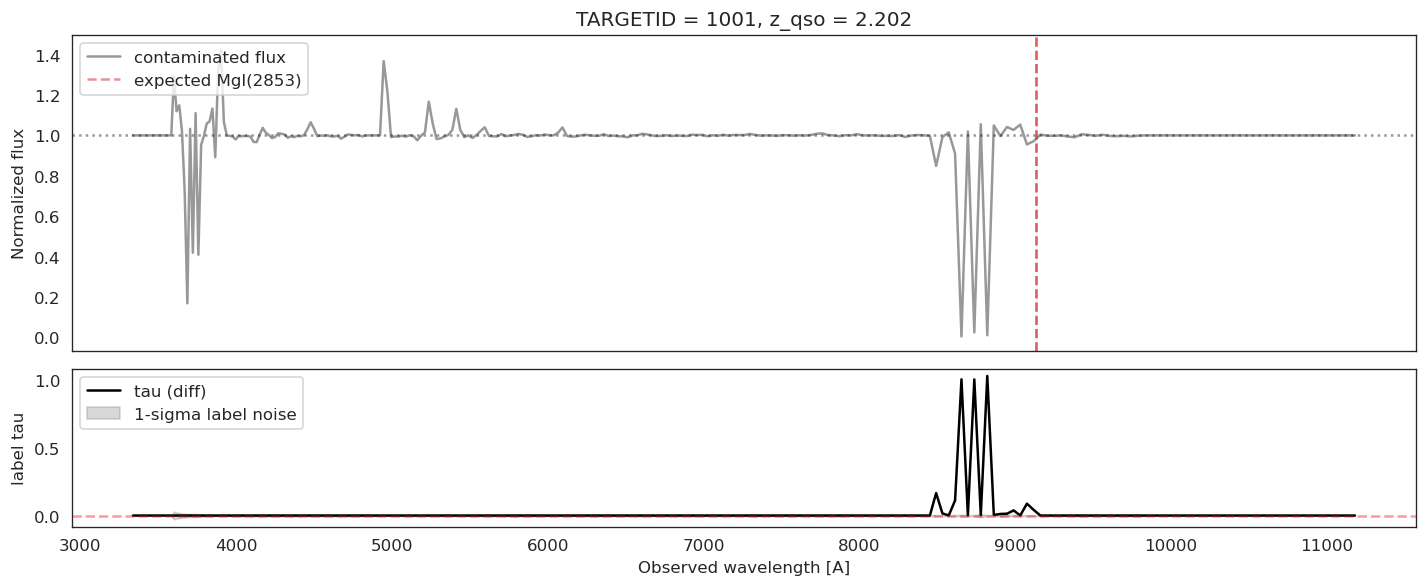

In [89]:
example_tid = common_ids[common_index]
example_sample = build_paired_sample(
    example_tid, uncontaminated_path, contaminated_path,
    spectra_uncontam=spectra_uncontam, spectra_contam=spectra_contam,
)
if example_sample is None:
    raise RuntimeError(
        f"TARGETID {example_tid} has no forest coverage in the fixed rest-frame "
        "window -- pick a different target from common_ids to sanity-check."
    )
 
z_qso_ex = example_sample["z_qso"]
obs_wave_ex = REST_GRID * (1 + z_qso_ex)
label_sigma = np.zeros(N_PIX)
w = example_sample["weight"][0]
label_sigma[w > 0] = 1.0 / np.sqrt(w[w > 0])
 
fig, (axf, axt) = plt.subplots(
    2, 1, figsize=(12, 5), dpi=120, sharex=True,
    gridspec_kw={"height_ratios": [3, 1.5]},
)
axf.plot(obs_wave_ex, example_sample["flux"], color="tab:gray", alpha=0.8, label="contaminated flux")
axf.axhline(1.0, color="k", ls=":", alpha=0.4)
# axf.axvline(1304.37 * (1 + z_qso_ex), color="tab:red", ls="--", alpha=0.5, label="expected SiII(1304)")
axf.axvline(2852.96 * (1 + z_qso_ex), color="tab:red", ls="--", alpha=0.5, label="expected MgI(2853)")
axf.set_ylabel("Normalized flux")
axf.set_title(f"TARGETID = {example_tid}, z_qso = {z_qso_ex:.3f}")
axf.legend(loc="upper left")
 
axt.plot(obs_wave_ex, example_sample["label"][0], color="k", label="tau (diff)")
axt.fill_between(obs_wave_ex, -label_sigma, label_sigma, color="tab:gray", alpha=0.3, label="1-sigma label noise")
axt.axhline(0, color="r", ls="--", alpha=0.4)
# axf.axvline(1304.37 * (1 + z_qso_ex), color="tab:red", ls="--", alpha=0.5, label="expected SiII(1304)")
axf.axvline(2852.96 * (1 + z_qso_ex), color="tab:red", ls="--", alpha=0.5, label="expected MgI(2853)")
axt.set_ylabel("label tau")
axt.set_xlabel("Observed wavelength [A]")
axt.legend(loc="upper left")
plt.tight_layout()
plt.show()

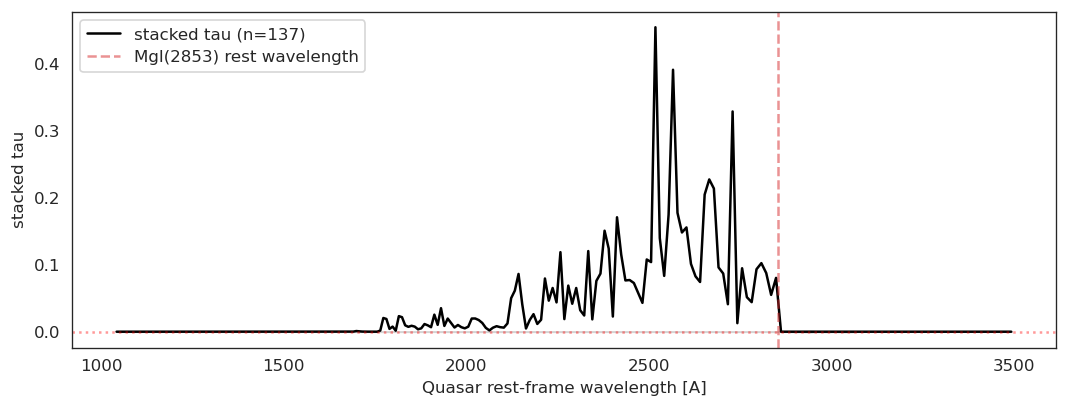

In [90]:

stack_num = np.zeros(N_PIX)
stack_den = np.zeros(N_PIX)
n_stacked = 0
for tid in common_ids[:200]:
    s = build_paired_sample(
        tid, uncontaminated_path, contaminated_path,
        spectra_uncontam=spectra_uncontam, spectra_contam=spectra_contam,
    )
    if s is None:
        continue
    w = s["weight"][0]
    stack_num += s["label"][0] * w
    stack_den += w
    n_stacked += 1
 
stacked_label = np.divide(stack_num, stack_den, out=np.zeros(N_PIX), where=stack_den > 0)
stacked_sigma = np.zeros(N_PIX)
stacked_sigma[stack_den > 0] = 1.0 / np.sqrt(stack_den[stack_den > 0])
 
plt.figure(figsize=(9, 3.5), dpi=120)
plt.plot(REST_GRID, stacked_label, color="k", label=f"stacked tau (n={n_stacked})")
plt.fill_between(REST_GRID, -stacked_sigma, stacked_sigma, color="tab:gray", alpha=0.3)
# plt.axvline(1304.37, color="tab:red", ls="--", alpha=0.5, label="SiII(1304) rest wavelength")
plt.axvline(2852.96, color="tab:red", ls="--", alpha=0.5, label="MgI(2853) rest wavelength")
plt.axhline(0, color="r", ls=":", alpha=0.4)
plt.xlabel("Quasar rest-frame wavelength [A]")
plt.ylabel("stacked tau")
plt.legend()
plt.tight_layout()
plt.show()

### 11.3 Check the output

First a couple of individual spectra with the full plot (predicted vs.
true tau, detected line markers), then aggregate completeness/purity and
strength-recovery stats across the *entire* validation set so you're not
judging performance off one or two cherry-picked examples.



MgI(2853):
  Metal rest wave: 2852.96 Å
  Metal pixel: 212
  REST_GRID[212]: 2847.83 Å
  Signal region: pixels 0 to 213
  Signal tau range: [0.000000, 0.761757]
  Noise level: 0.000100
  Raw peaks found: 8
    Pixels: [187 190 196 199 203 206 209 212]
    Tau values: [0.46520478 0.3939615  0.76175696 0.03724122 0.10076988 0.03123941
 0.26827705 0.26967525]
    ✓ Accepted: pix 187, z_abs=2.015, τ=0.4652
    ✓ Accepted: pix 190, z_abs=2.058, τ=0.3940
    ✓ Accepted: pix 196, z_abs=2.147, τ=0.7618
    ✓ Accepted: pix 199, z_abs=2.192, τ=0.0372
    ✓ Accepted: pix 203, z_abs=2.253, τ=0.1008
    ✓ Accepted: pix 206, z_abs=2.299, τ=0.0312
    ✓ Accepted: pix 209, z_abs=2.347, τ=0.2683
    ✓ Accepted: pix 212, z_abs=2.395, τ=0.2697

MgI(2853):
  Metal rest wave: 2852.96 Å
  Metal pixel: 212
  REST_GRID[212]: 2847.83 Å
  Signal region: pixels 0 to 213
  Signal tau range: [0.000000, 1.009856]
  Noise level: 0.000100
  Raw peaks found: 7
    Pixels: [186 190 195 198 201 207 211]
    Tau values:

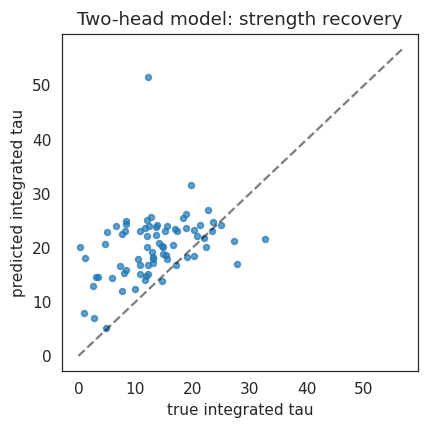

In [91]:
all_matched, all_missed, all_fp = [], [], []
for s in val_samples:
    detect_logits, strength_pred = predict_two_head(model, s, device=device)
    true_dets = extract_lines_v4(s["label"], s["z_qso"], REST_GRID, METAL_LINES)
    pred_dets = extract_lines_two_head(detect_logits, strength_pred, s["z_qso"], REST_GRID, METAL_LINES)
    matched, missed, false_pos = match_detections_v2(true_dets, pred_dets, tol_pix=3)
    all_matched += matched
    all_missed += missed
    all_fp += false_pos

n_true = len(all_matched) + len(all_missed)
n_pred = len(all_matched) + len(all_fp)
completeness = len(all_matched) / n_true if n_true else float("nan")
purity = len(all_matched) / n_pred if n_pred else float("nan")

print(f"validation set: {len(val_samples)} spectra")
print(f"true lines:     {n_true}")
print(f"predicted:      {n_pred}")
print(f"completeness:   {completeness:.2f}")
print(f"purity:         {purity:.2f}")

if all_matched:
    true_s = np.array([m[0]["integrated_tau"] for m in all_matched])
    pred_s = np.array([m[1]["integrated_tau"] for m in all_matched])
    print(f"strength bias:    {np.mean(pred_s - true_s):.4f}")
    print(f"strength scatter: {np.std(pred_s - true_s):.4f}")

    plt.figure(figsize=(4, 4), dpi=110)
    lims = [0, max(true_s.max(), pred_s.max()) * 1.1 + 1e-6]
    plt.plot(lims, lims, "k--", alpha=0.5)
    plt.scatter(true_s, pred_s, s=15, alpha=0.7)
    plt.xlabel("true integrated tau")
    plt.ylabel("predicted integrated tau")
    plt.title("Two-head model: strength recovery")
    plt.tight_layout()
    plt.show()


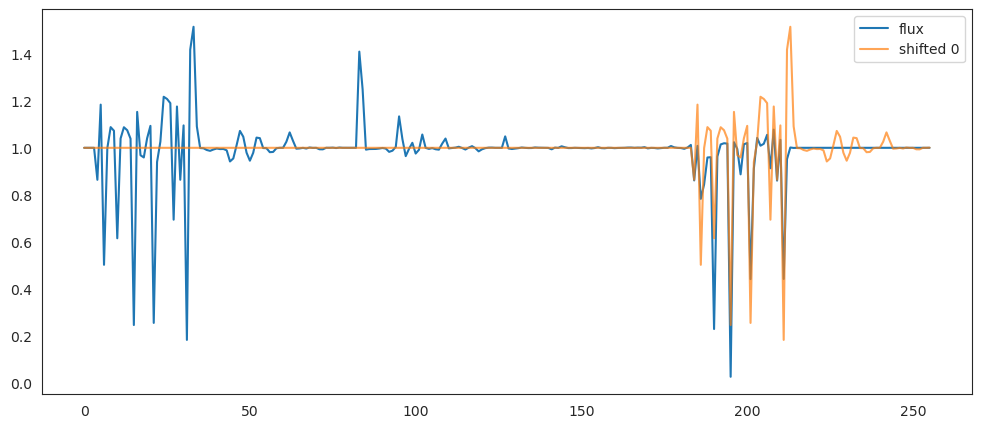

In [92]:
plt.figure(figsize=(12, 5))

plt.plot(
    _sample["flux"],
    label="flux",
)

shifted = make_shifted_channels(_sample["flux"])

for i in range(shifted.shape[0]):
    plt.plot(
        shifted[i],
        label=f"shifted {i}",
        alpha=0.7,
    )

# plt.xlim(0, 50)
plt.legend()
plt.show()

In [93]:
detect_logits, strength_pred = predict_two_head(
    model, val_samples[1], device=device
)

probs = torch.sigmoid(
    torch.from_numpy(detect_logits)
).numpy()

print("Logit stats:")
print("  min:", detect_logits.min())
print("  max:", detect_logits.max())
print("  mean:", detect_logits.mean())

print("\nProbability stats:")
print("  min:", probs.min())
print("  max:", probs.max())
print("  mean:", probs.mean())

for threshold in [0.01, 0.05, 0.1, 0.2, 0.3, 0.5]:
    print(f"pixels > {threshold}: {(probs > threshold).sum()}")

Logit stats:
  min: -26.214725
  max: 1.1495241
  mean: -4.7277236

Probability stats:
  min: 4.1218235e-12
  max: 0.759424
  mean: 0.15073669
pixels > 0.01: 223
pixels > 0.05: 214
pixels > 0.1: 41
pixels > 0.2: 38
pixels > 0.3: 36
pixels > 0.5: 33


In [94]:
# plt.figure(figsize=(12, 4))

# plt.plot(
#     probs[0],
#     label="detection probability",
# )

# plt.axhline(0.5, ls="--")

# # plt.xlim(0, 50)
# # plt.ylim(0, 1)

# plt.legend()
# plt.show()

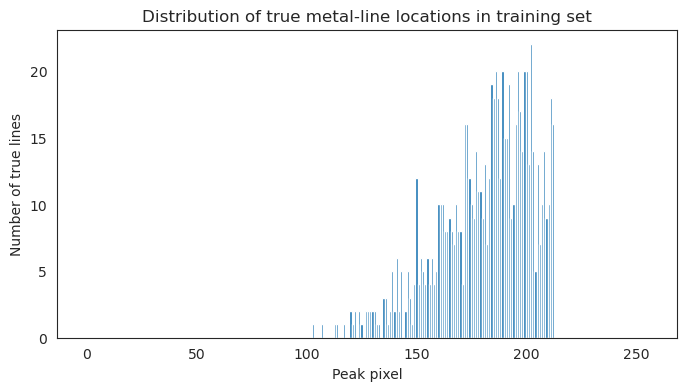

In [95]:
all_peak_pixels = []

for s in train_samples:
    labels = s["label"]

    for metal in range(labels.shape[0]):
        peaks, _ = find_peaks(
            labels[metal],
            height=0.01,
            distance=3,
        )
        all_peak_pixels.extend(peaks)

plt.figure(figsize=(8, 4))
plt.hist(all_peak_pixels, bins=np.arange(257) - 0.5)
plt.xlabel("Peak pixel")
plt.ylabel("Number of true lines")
plt.title("Distribution of true metal-line locations in training set")
plt.show()

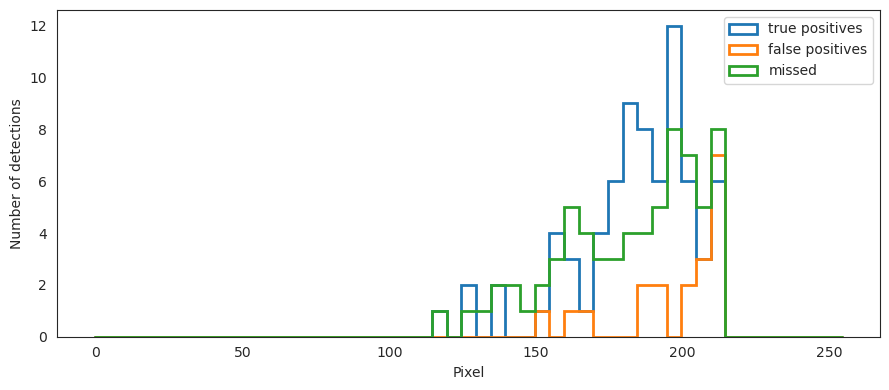

In [96]:
tp_pix = np.array([
    m[1]["pixel"] for m in all_matched
])

fp_pix = np.array([
    d["pixel"] for d in all_fp
])

miss_pix = np.array([
    d["pixel"] for d in all_missed
])

plt.figure(figsize=(9, 4))

bins = np.arange(-0.5, 256.5, 5)

plt.hist(tp_pix, bins=bins, histtype="step", linewidth=2, label="true positives")
plt.hist(fp_pix, bins=bins, histtype="step", linewidth=2, label="false positives")
plt.hist(miss_pix, bins=bins, histtype="step", linewidth=2, label="missed")

plt.xlabel("Pixel")
plt.ylabel("Number of detections")
plt.legend()
plt.tight_layout()
plt.show()

In [97]:
# true_pix = []

# for s in val_samples:
#     for m in range(s["label"].shape[0]):
#         peaks, _ = find_peaks(
#             s["label"][m],
#             height=0.01,
#             distance=3
#         )
#         true_pix.extend(peaks)

# plt.figure(figsize=(9, 4))

# plt.hist(true_pix, bins=bins, histtype="step", linewidth=2, label="all true lines")
# plt.hist(fp_pix, bins=bins, histtype="step", linewidth=2, label="false positives")

# plt.xlabel("Pixel")
# plt.ylabel("Count")
# plt.legend()
# plt.tight_layout()
# plt.show()

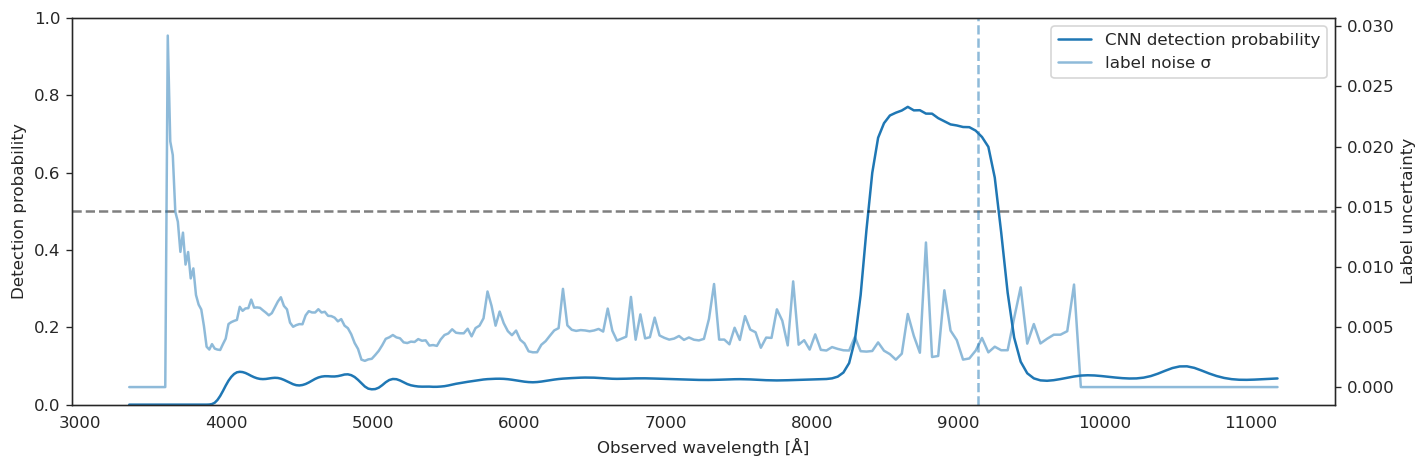

In [100]:
label_sigma = np.zeros(N_PIX)
w = example_sample["weight"][0]
label_sigma[w > 0] = 1.0 / np.sqrt(w[w > 0])

detect_logits, strength_pred = predict_two_head(
    model,
    example_sample,
    device=device,
)

prob = 1 / (1 + np.exp(-detect_logits[0]))

fig, ax1 = plt.subplots(figsize=(12, 4), dpi=120)

ax1.plot(
    obs_wave_ex,
    prob,
    label="CNN detection probability",
)
ax1.axhline(0.5, color="k", ls="--", alpha=0.5)
ax1.set_ylabel("Detection probability")
ax1.set_ylim(0, 1)

ax2 = ax1.twinx()

ax2.plot(
    obs_wave_ex,
    label_sigma,
    alpha=0.5,
    label="label noise σ",
)
ax2.set_ylabel("Label uncertainty")

ax1.axvline(
    2852.96 * (1 + z_qso_ex),
    ls="--",
    alpha=0.5,
)

ax1.set_xlabel("Observed wavelength [Å]")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
)

plt.tight_layout()
plt.show()

In [101]:
def plot_prediction_vs_truth_verbose(
    model,
    sample,
    device="cpu",
    tol_pix=3,
    prob_threshold=0.5,
    distance=3,
):
    """
    Plot CNN prediction vs truth for the two-head metal-line detector.

    Top panel:
        Contaminated input flux with matched, missed, and false-positive
        detections marked.

    Bottom panel:
        True metal optical depth and CNN-predicted metal strength.

    Detection:
        Uses the two-head detection probability rather than treating the
        strength prediction itself as the detection criterion.

    Parameters
    ----------
    model : TwoHeadMetalCNN
        Trained two-head model.

    sample : dict
        Sample containing at least:
            "flux", "ivar", "z_qso", "label", "targetid"

    device : torch.device or str
        Device on which the model is located.

    tol_pix : int
        Pixel tolerance used for matching predicted and true detections.

    prob_threshold : float
        Detection-probability threshold passed to extract_lines_two_head.

    distance : int
        Minimum pixel separation between detected peaks.
    """

    model.eval()

    # ------------------------------------------------------------------
    # 1. Prepare input
    # ------------------------------------------------------------------

    flux = sample["flux"].astype(np.float32)
    ivar = sample["ivar"].astype(np.float32)

    # Normalize inverse variance exactly as during training
    IVAR_SCALE = 1e7
    ivar = ivar / IVAR_SCALE

    # Existing metal-shifted channels
    shifted = make_shifted_channels(flux).astype(np.float32)

    z_qso = sample["z_qso"]
    true_label = sample["label"]

    obs_wave = REST_GRID * (1.0 + z_qso)

    # Binary Lyα forest channel
    lya_mask = make_lya_binary_channel(REST_GRID)
    # z_abs = make_absorber_z_channel(z_qso, REST_GRID, METAL_LINES['MgI(2853)'])

    # lya_structure = make_lya_structure_channel(flux)
    
    # Input:
    #   channel 0       = flux
    #   channel 1       = ivar
    #   channels 2...   = shifted metal channels
    #   final channel   = Lyα mask
    
    x = np.concatenate([flux[None, :], ivar[None, :], 
                        shifted, lya_mask[None,:], 
                        # z_abs[None,:],
                        # lya_structure[None,:]
                       ], 
                       axis=0)
    

    x_t = torch.from_numpy(x).unsqueeze(0).to(device)

    # ------------------------------------------------------------------
    # 2. CNN prediction
    # ------------------------------------------------------------------

    with torch.no_grad():
        detect_logits, strength_pred = model(x_t)

    detect_logits = detect_logits[0].cpu().numpy()
    strength_pred = strength_pred[0].cpu().numpy()

    # ------------------------------------------------------------------
    # 3. Observed wavelength
    # ------------------------------------------------------------------

    # z_qso = sample["z_qso"]
    # true_label = sample["label"]

    # obs_wave = REST_GRID * (1.0 + z_qso)

    # ------------------------------------------------------------------
    # 4. Extract truth and CNN detections
    # ------------------------------------------------------------------

    true_dets = extract_lines_v4(
        true_label,
        z_qso,
        REST_GRID,
        METAL_LINES,
        min_peak_tau=0.01,
        distance=distance,
    )

    pred_dets = extract_lines_two_head(
        detect_logits,
        strength_pred,
        z_qso,
        REST_GRID,
        METAL_LINES,
        prob_threshold=prob_threshold,
        distance=distance,
    )

    # Match detections
    matched, missed, false_pos = match_detections_v2(
        true_dets,
        pred_dets,
        tol_pix=tol_pix,
    )

    # ------------------------------------------------------------------
    # 5. Plot
    # ------------------------------------------------------------------

    fig, (ax1, ax2) = plt.subplots(
        2,
        1,
        figsize=(15, 8),
        dpi=120,
        sharex=True,
        gridspec_kw={"height_ratios": [3, 2]},
    )

    # ==============================================================
    # TOP PANEL: contaminated flux
    # ==============================================================

    ax1.plot(
        obs_wave,
        flux,
        color="tab:gray",
        alpha=0.8,
        linewidth=1.2,
        label="contaminated flux",
    )

    ax1.axhline(
        1.0,
        color="k",
        ls=":",
        alpha=0.4,
        linewidth=1,
    )

    ax1.set_ylabel("Normalized flux", fontsize=11)

    ax1.set_title(
        f"TARGETID = {sample['targetid']}   "
        f"$z_{{qso}}$ = {z_qso:.3f}\n"
        f"True: {len(true_dets)} | "
        f"Pred: {len(pred_dets)} | "
        f"Matched: {len(matched)} | "
        f"Missed: {len(missed)} | "
        f"FP: {len(false_pos)} | "
        f"Purity: "
        f"{len(matched)/len(pred_dets):.2f}"
        if pred_dets
        else "N/A",
        fontsize=12,
        weight="bold",
    )

    ax1.set_ylim([0.85, 1.05])
    ax1.grid(True, alpha=0.2)

    # ==============================================================
    # BOTTOM PANEL: true vs predicted strength
    # ==============================================================

    for i, name in enumerate(METAL_NAMES):

        ax2.plot(
            obs_wave,
            true_label[i],
            color="k",
            alpha=0.5,
            linewidth=1.5,
            label="true τ" if i == 0 else None,
        )

        ax2.plot(
            obs_wave,
            strength_pred[i],
            color="tab:red",
            alpha=0.7,
            linewidth=1.5,
            label="CNN strength" if i == 0 else None,
        )

    # ==============================================================
    # MATCHED DETECTIONS -- GREEN
    # ==============================================================

    for j, (td, pd) in enumerate(matched):

        obsw = REST_GRID[td["pixel"]] * (1 + z_qso)

        ax1.axvline(
            obsw,
            color="green",
            ls="-",
            alpha=0.75,
            linewidth=2.5,
            label="matched" if j == 0 else None,
        )

        ax2.axvline(
            obsw,
            color="green",
            ls="-",
            alpha=0.75,
            linewidth=2.5,
        )

        # True and predicted values
        tau_true = td["peak_tau"]
        tau_pred = pd["peak_tau"]
        prob = pd["detect_prob"]

        # Annotate predicted probability and strength
        ymax = max(true_label.max(), strength_pred.max(), 0.05)

        ax2.text(
            obsw,
            ymax * 0.92,
            f"{prob:.2f}\n"
            f"$\\tau$: {tau_true:.2f} → {tau_pred:.2f}",
            ha="center",
            va="top",
            fontsize=7,
            color="green",
            weight="bold",
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="white",
                alpha=0.75,
            ),
        )

    # ==============================================================
    # MISSED DETECTIONS -- ORANGE
    # ==============================================================

    for j, td in enumerate(missed):

        obsw = REST_GRID[td["pixel"]] * (1 + z_qso)

        ax1.axvline(
            obsw,
            color="orange",
            ls="--",
            alpha=0.8,
            linewidth=2,
            label="missed (FN)" if j == 0 else None,
        )

        ax2.axvline(
            obsw,
            color="orange",
            ls="--",
            alpha=0.8,
            linewidth=2,
        )

        tau_true = td["peak_tau"]

        ymax = max(true_label.max(), strength_pred.max(), 0.05)

        ax2.text(
            obsw,
            ymax * 0.92,
            f"MISS\n"
            f"$\\tau$ = {tau_true:.2f}",
            ha="center",
            va="top",
            fontsize=7,
            color="orange",
            weight="bold",
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="white",
                alpha=0.75,
            ),
        )

    # ==============================================================
    # FALSE POSITIVES -- RED
    # ==============================================================

    for j, pd in enumerate(false_pos):

        obsw = REST_GRID[pd["pixel"]] * (1 + z_qso)

        ax1.axvline(
            obsw,
            color="red",
            ls=":",
            alpha=0.8,
            linewidth=2,
            label="false positive" if j == 0 else None,
        )

        ax2.axvline(
            obsw,
            color="red",
            ls=":",
            alpha=0.8,
            linewidth=2,
        )

        prob = pd["detect_prob"]
        tau_pred = pd["peak_tau"]

        ymax = max(true_label.max(), strength_pred.max(), 0.05)

        ax2.text(
            obsw,
            ymax * 0.55,
            f"FP\n"
            f"$P$ = {prob:.2f}\n"
            f"$\\tau$ = {tau_pred:.2f}",
            ha="center",
            va="top",
            fontsize=7,
            color="red",
            weight="bold",
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="white",
                alpha=0.75,
            ),
        )

    # Detection threshold annotation
    ax2.legend(
        loc="upper right",
        fontsize=9,
    )

    ax2.set_xlabel(
        "Observed wavelength [Å]",
        fontsize=11,
    )

    ax2.set_ylabel(
        "Optical depth / strength",
        fontsize=11,
    )

    ymax = max(
        true_label.max(),
        strength_pred.max(),
        0.05,
    )

    ax2.set_ylim(
        min(-0.05, strength_pred.min() * 1.1),
        ymax * 1.3,
    )

    ax2.grid(True, alpha=0.2)

    # --------------------------------------------------------------
    # Show Lyα forest region
    # --------------------------------------------------------------

    lya_obs_min = LYA_MIN * (1 + z_qso)
    lya_obs_max = LYA_MAX * (1 + z_qso)

    ax1.axvspan(
        lya_obs_min,
        lya_obs_max,
        alpha=0.08,
        label="Lyα forest",
    )

    ax2.axvspan(
        lya_obs_min,
        lya_obs_max,
        alpha=0.08,
    )

    # Rebuild top legend so the Lyα region is included
    ax1.legend(
        loc="lower right",
        fontsize=9,
    )

    plt.tight_layout()
    plt.show()

    # ==============================================================
    # 6. Print detection statistics
    # ==============================================================

    print("\n" + "=" * 60)
    print(
        f"TARGETID {sample['targetid']} | "
        f"z_qso = {z_qso:.3f}"
    )
    print("=" * 60)

    print(f"True detections:  {len(true_dets)}")
    print(f"Pred detections:  {len(pred_dets)}")
    print(f"Matched:          {len(matched)}")
    print(f"Missed (FN):      {len(missed)}")
    print(f"False positives:  {len(false_pos)}")

    if pred_dets:
        print(
            f"Purity:           "
            f"{len(matched) / len(pred_dets):.3f}"
        )

    if true_dets:
        print(
            f"Completeness:     "
            f"{len(matched) / len(true_dets):.3f}"
        )

    # ==============================================================
    # 7. Matched detections
    # ==============================================================

    if matched:

        print("\n--- MATCHED DETECTIONS ---")

        for td, pd in matched:

            print(
                f"  {td['metal_name']:15s}: "
                f"z={td['z_absorber']:.3f} | "
                f"τ_true={td['peak_tau']:.4f} → "
                f"τ_pred={pd['peak_tau']:.4f} | "
                f"P={pd['detect_prob']:.3f} | "
                f"pix_offset="
                f"{pd['pixel'] - td['pixel']:+d}"
            )

        true_strength = np.array(
            [m[0]["integrated_tau"] for m in matched]
        )

        pred_strength = np.array(
            [m[1]["integrated_tau"] for m in matched]
        )

        bias = np.mean(
            pred_strength - true_strength
        )

        scatter = np.std(
            pred_strength - true_strength
        )

        rmse = np.sqrt(
            np.mean(
                (pred_strength - true_strength) ** 2
            )
        )

        print("\nStrength recovery:")
        print(f"  bias:    {bias:+.4f}")
        print(f"  scatter: {scatter:.4f}")
        print(f"  RMSE:    {rmse:.4f}")

    # ==============================================================
    # 8. Missed detections
    # ==============================================================

    if missed:

        print("\n--- MISSED DETECTIONS ---")

        for td in missed:

            print(
                f"  {td['metal_name']:15s}: "
                f"z={td['z_absorber']:.3f} | "
                f"τ={td['peak_tau']:.4f} | "
                f"pix={td['pixel']}"
            )

    # ==============================================================
    # 9. False positives
    # ==============================================================

    if false_pos:

        print("\n--- FALSE POSITIVES ---")

        for pd in false_pos:

            print(
                f"  {pd['metal_name']:15s}: "
                f"z={pd['z_absorber']:.3f} | "
                f"P={pd['detect_prob']:.3f} | "
                f"τ_pred={pd['peak_tau']:.4f} | "
                f"pix={pd['pixel']}"
            )

    print("=" * 60 + "\n")

    return {
        "matched": matched,
        "missed": missed,
        "false_pos": false_pos,
        "true_dets": true_dets,
        "pred_dets": pred_dets,
        "detect_logits": detect_logits,
        "strength_pred": strength_pred,
    }


MgI(2853):
  Metal rest wave: 2852.96 Å
  Metal pixel: 212
  REST_GRID[212]: 2847.83 Å
  Signal region: pixels 0 to 213
  Signal tau range: [0.000000, 0.761757]
  Noise level: 0.000100
  Raw peaks found: 8
    Pixels: [187 190 196 199 203 206 209 212]
    Tau values: [0.46520478 0.3939615  0.76175696 0.03724122 0.10076988 0.03123941
 0.26827705 0.26967525]
    ✓ Accepted: pix 187, z_abs=2.015, τ=0.4652
    ✓ Accepted: pix 190, z_abs=2.058, τ=0.3940
    ✓ Accepted: pix 196, z_abs=2.147, τ=0.7618
    ✓ Accepted: pix 199, z_abs=2.192, τ=0.0372
    ✓ Accepted: pix 203, z_abs=2.253, τ=0.1008
    ✓ Accepted: pix 206, z_abs=2.299, τ=0.0312
    ✓ Accepted: pix 209, z_abs=2.347, τ=0.2683
    ✓ Accepted: pix 212, z_abs=2.395, τ=0.2697


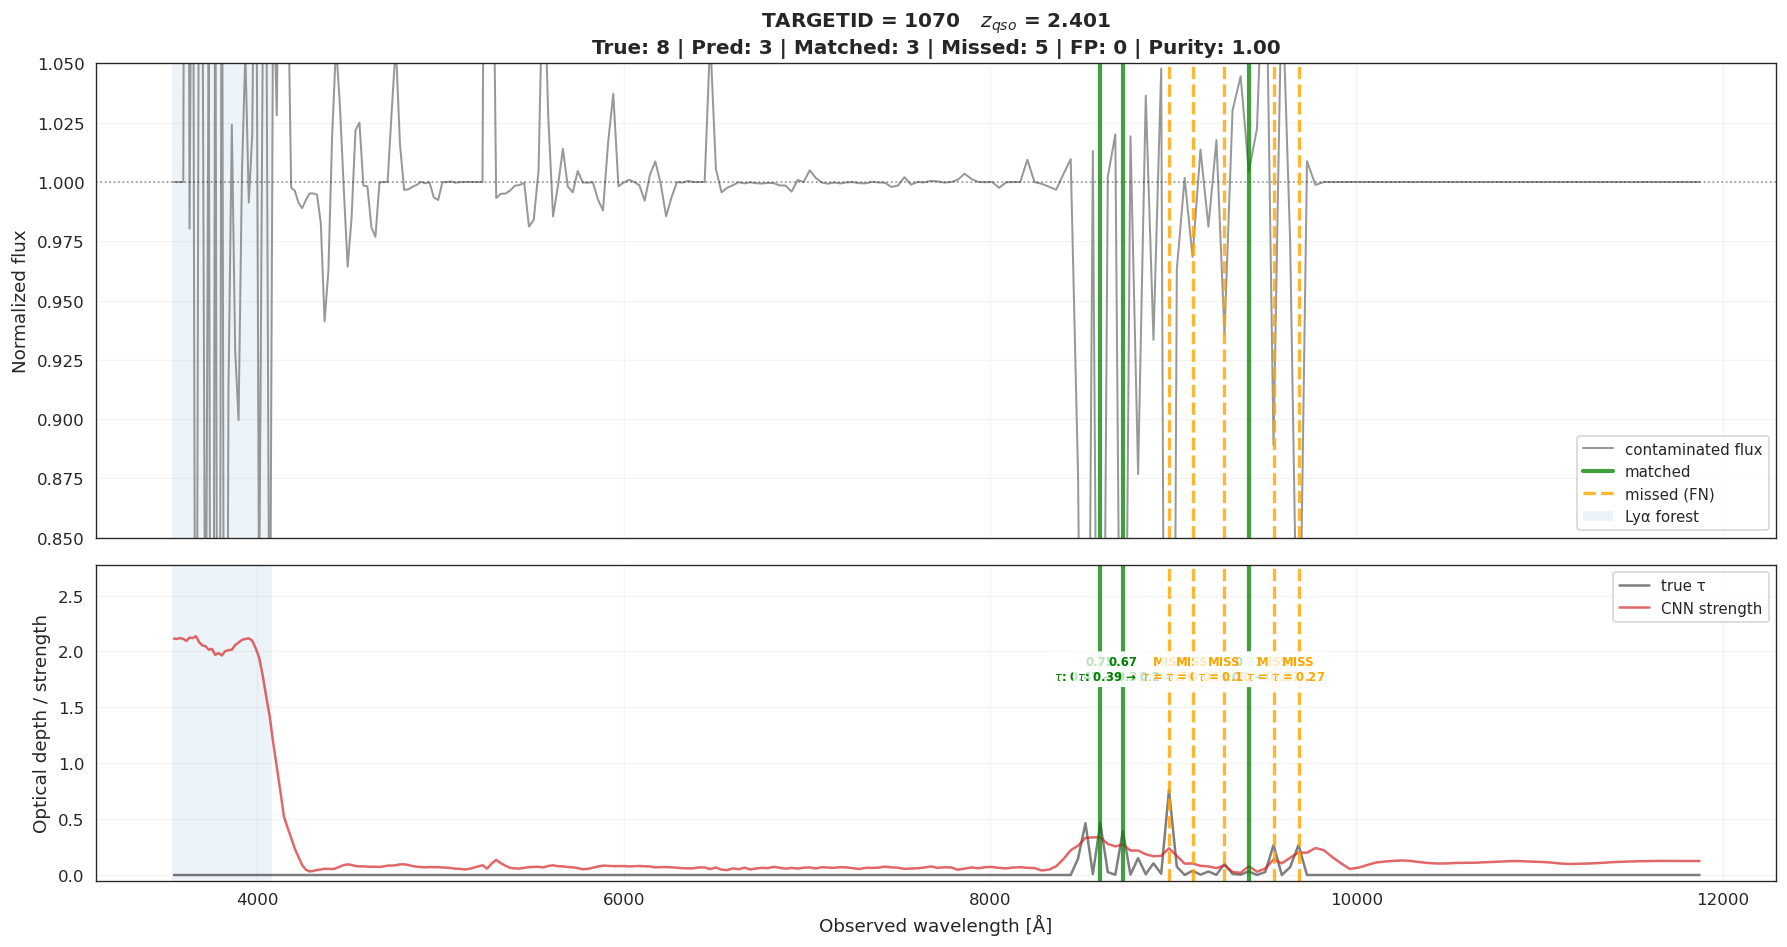


TARGETID 1070 | z_qso = 2.401
True detections:  8
Pred detections:  3
Matched:          3
Missed (FN):      5
False positives:  0
Purity:           1.000
Completeness:     0.375

--- MATCHED DETECTIONS ---
  MgI(2853)      : z=2.015 | τ_true=0.4652 → τ_pred=0.3320 | P=0.749 | pix_offset=-2
  MgI(2853)      : z=2.058 | τ_true=0.3940 → τ_pred=0.2391 | P=0.671 | pix_offset=+6
  MgI(2853)      : z=2.299 | τ_true=0.0312 → τ_pred=0.2015 | P=0.713 | pix_offset=+6

Strength recovery:
  bias:    +6.4125
  scatter: 3.6114
  RMSE:    7.3595

--- MISSED DETECTIONS ---
  MgI(2853)      : z=2.147 | τ=0.7618 | pix=196
  MgI(2853)      : z=2.192 | τ=0.0372 | pix=199
  MgI(2853)      : z=2.253 | τ=0.1008 | pix=203
  MgI(2853)      : z=2.347 | τ=0.2683 | pix=209
  MgI(2853)      : z=2.395 | τ=0.2697 | pix=212



{'matched': [({'metal_name': 'MgI(2853)',
    'pixel': 187,
    'rest_wavelength_A': 2852.96,
    'z_absorber': 2.0152612837679267,
    'peak_tau': 0.46520477533340454,
    'integrated_tau': 14.788626109520294,
    'measured_width_pixels': 2.0,
    'measured_width_angstrom': 19.218588991592625,
    'measured_width_kms': 2020.910457026312,
    'snr': 4652.047753334045,
    'prominence': 0.4625379752833396,
    'noise_level': 0.0001},
   {'metal_name': 'MgI(2853)',
    'pixel': 185,
    'rest_wavelength_A': 2852.96,
    'z_absorber': 1.9868092849538521,
    'detect_prob': 0.7490806579589844,
    'peak_tau': 0.3320005238056183,
    'integrated_tau': 20.213311665331254}),
  ({'metal_name': 'MgI(2853)',
    'pixel': 190,
    'rest_wavelength_A': 2852.96,
    'z_absorber': 2.05844826992113,
    'peak_tau': 0.39396148920059204,
    'integrated_tau': 9.869272915279286,
    'measured_width_pixels': 2.0,
    'measured_width_angstrom': 19.218588991592625,
    'measured_width_kms': 2020.9104570263

In [102]:
plot_prediction_vs_truth_verbose(
    model,
    # sample,
    val_samples[0],
    device="cpu",
    tol_pix=3,
    prob_threshold=0.5,
    distance=3,
)

In [103]:
def plot_strength_diagnostics(
    model,
    samples,
    device="cpu",
    prob_threshold=0.5,
    distance=3,
    tol_pix=3,
    max_samples=None,
):
    """
    Compare predicted vs. true metal-line strengths for matched detections.

    Produces:
        1. True vs predicted peak tau
        2. True vs predicted integrated tau
        3. Fractional / absolute residuals vs true strength
        4. Histograms of true and predicted strengths

    Only matched detections are included in the strength comparison.

    Parameters
    ----------
    model : TwoHeadMetalCNN
        Trained model.

    samples : list of dict
        Validation/test samples.

    device : torch.device or str
        Model device.

    prob_threshold : float
        Detection probability threshold.

    distance : int
        Minimum peak separation.

    tol_pix : int
        Pixel tolerance for matching detections.

    max_samples : int or None
        Optional limit on number of samples to process.
    """

    model.eval()

    if max_samples is not None:
        samples_to_use = samples[:max_samples]
    else:
        samples_to_use = samples

    all_matched = []

    # ------------------------------------------------------------
    # Run model and collect matched detections
    # ------------------------------------------------------------

    for sample in samples_to_use:

        flux = sample["flux"].astype(np.float32)
        ivar = sample["ivar"].astype(np.float32)

        IVAR_SCALE = 1e7
        ivar = ivar / IVAR_SCALE

        shifted = make_shifted_channels(flux).astype(np.float32)
        lya_mask = make_lya_binary_channel(REST_GRID)

        x = np.concatenate(
            [
                flux[None, :],
                ivar[None, :],
                shifted,
                lya_mask[None, :],
            ],
            axis=0,
        )

        x_t = torch.from_numpy(x).unsqueeze(0).to(device)

        with torch.no_grad():
            detect_logits, strength_pred = model(x_t)

        detect_logits = detect_logits[0].cpu().numpy()
        strength_pred = strength_pred[0].cpu().numpy()

        # Truth
        true_dets = extract_lines_v4(
            sample["label"],
            sample["z_qso"],
            REST_GRID,
            METAL_LINES,
            min_peak_tau=0.001,
            distance=distance,
        )

        # Prediction
        pred_dets = extract_lines_two_head(
            detect_logits,
            strength_pred,
            sample["z_qso"],
            REST_GRID,
            METAL_LINES,
            prob_threshold=prob_threshold,
            distance=distance,
        )

        matched, missed, false_pos = match_detections_v2(
            true_dets,
            pred_dets,
            tol_pix=tol_pix,
        )

        all_matched.extend(matched)

    # ------------------------------------------------------------
    # Check for matches
    # ------------------------------------------------------------

    if len(all_matched) == 0:
        print("No matched detections found.")
        return None

    # ------------------------------------------------------------
    # Extract strengths
    # ------------------------------------------------------------

    true_peak = np.array(
        [m[0]["peak_tau"] for m in all_matched]
    )

    pred_peak = np.array(
        [m[1]["peak_tau"] for m in all_matched]
    )

    true_integrated = np.array(
        [m[0]["integrated_tau"] for m in all_matched]
    )

    pred_integrated = np.array(
        [m[1]["integrated_tau"] for m in all_matched]
    )

    # Residuals
    peak_residual = pred_peak - true_peak
    integrated_residual = pred_integrated - true_integrated

    # Fractional residuals
    peak_frac = peak_residual / np.maximum(true_peak, 1e-6)
    integrated_frac = integrated_residual / np.maximum(
        true_integrated, 1e-6
    )

    # ------------------------------------------------------------
    # Statistics
    # ------------------------------------------------------------

    print("\n" + "=" * 60)
    print("STRENGTH RECOVERY DIAGNOSTICS")
    print("=" * 60)

    print(f"Matched detections: {len(all_matched)}")

    print("\nPeak tau:")
    print(f"  bias:    {np.mean(peak_residual):+.4f}")
    print(f"  scatter: {np.std(peak_residual):.4f}")
    print(
        f"  RMSE:    "
        f"{np.sqrt(np.mean(peak_residual**2)):.4f}"
    )

    print("\nIntegrated tau:")
    print(f"  bias:    {np.mean(integrated_residual):+.4f}")
    print(f"  scatter: {np.std(integrated_residual):.4f}")
    print(
        f"  RMSE:    "
        f"{np.sqrt(np.mean(integrated_residual**2)):.4f}"
    )

    print("\nMedian fractional residual:")
    print(f"  peak:       {np.median(peak_frac):+.3f}")
    print(f"  integrated: {np.median(integrated_frac):+.3f}")

    # ------------------------------------------------------------
    # Figure
    # ------------------------------------------------------------

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(12, 10),
        dpi=120,
    )

    ax1, ax2, ax3, ax4 = axes.flatten()

    # ============================================================
    # 1. Peak tau: true vs predicted
    # ============================================================

    ax1.scatter(
        true_peak,
        pred_peak,
        s=35,
        alpha=0.65,
        edgecolors="k",
        linewidths=0.5,
    )

    peak_max = max(
        true_peak.max(),
        pred_peak.max(),
    )

    lims = [0, peak_max * 1.05]

    ax1.plot(
        lims,
        lims,
        "k--",
        alpha=0.6,
        label="1:1",
    )

    ax1.set_xlim(lims)
    ax1.set_ylim(lims)

    ax1.set_xlabel("True peak τ")
    ax1.set_ylabel("Predicted peak τ")

    ax1.set_title("Peak Optical Depth Recovery")
    ax1.legend(loc='upper right')

    ax1.text(
        0.05,
        0.95,
        f"Bias = {np.mean(peak_residual):+.3f}\n"
        f"Scatter = {np.std(peak_residual):.3f}",
        transform=ax1.transAxes,
        va="top",
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.8,
        ),
    )

    # ============================================================
    # 2. Integrated tau: true vs predicted
    # ============================================================

    ax2.scatter(
        true_integrated,
        pred_integrated,
        s=35,
        alpha=0.65,
        edgecolors="k",
        linewidths=0.5,
    )

    int_max = max(
        true_integrated.max(),
        pred_integrated.max(),
    )

    lims = [0, int_max * 1.05]

    ax2.plot(
        lims,
        lims,
        "k--",
        alpha=0.6,
        label="1:1",
    )

    ax2.set_xlim(lims)
    ax2.set_ylim(lims)

    ax2.set_xlabel("True integrated τ")
    ax2.set_ylabel("Predicted integrated τ")

    ax2.set_title("Integrated Optical Depth Recovery")
    ax2.legend(loc='upper right')

    ax2.text(
        0.05,
        0.95,
        f"Bias = {np.mean(integrated_residual):+.3f}\n"
        f"Scatter = {np.std(integrated_residual):.3f}",
        transform=ax2.transAxes,
        va="top",
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.8,
        ),
    )

    # ============================================================
    # 3. Peak residuals vs true strength
    # ============================================================

    ax3.axhline(
        0,
        color="k",
        ls="--",
        alpha=0.5,
    )

    ax3.scatter(
        true_peak,
        peak_residual,
        s=35,
        alpha=0.65,
        edgecolors="k",
        linewidths=0.5,
    )

    ax3.set_xlabel("True peak τ")
    ax3.set_ylabel("Predicted − true peak τ")

    ax3.set_title("Peak τ Residuals")

    ax3.grid(alpha=0.2)

    # ============================================================
    # 4. Strength distributions
    # ============================================================

    bins_peak = np.linspace(
        0,
        max(
            true_peak.max(),
            pred_peak.max(),
        ) * 1.05,
        20,
    )

    ax4.hist(
        true_peak,
        bins=bins_peak,
        alpha=0.55,
        label="True",
    )

    ax4.hist(
        pred_peak,
        bins=bins_peak,
        alpha=0.55,
        label="Predicted",
    )

    ax4.set_xlabel("Peak τ")
    ax4.set_ylabel("Count")

    ax4.set_title("Peak τ Distribution")

    ax4.legend()

    ax4.grid(
        axis="y",
        alpha=0.2,
    )

    fig.suptitle(
        "Metal-line Strength Recovery",
        fontsize=15,
        weight="bold",
    )

    plt.savefig('diagnostic_plot.png')

    plt.tight_layout()
    plt.show()

    return {
        "matched": all_matched,
        "true_peak": true_peak,
        "pred_peak": pred_peak,
        "true_integrated": true_integrated,
        "pred_integrated": pred_integrated,
        "peak_residual": peak_residual,
        "integrated_residual": integrated_residual,
        "peak_fractional_residual": peak_frac,
        "integrated_fractional_residual": integrated_frac,
    }


MgI(2853):
  Metal rest wave: 2852.96 Å
  Metal pixel: 212
  REST_GRID[212]: 2847.83 Å
  Signal region: pixels 0 to 213
  Signal tau range: [0.000000, 1.032160]
  Noise level: 0.000100
  Raw peaks found: 4
    Pixels: [197 201 205 211]
    Tau values: [0.16593114 1.0072619  1.0321597  0.08784933]
    ✓ Accepted: pix 197, z_abs=1.977, τ=0.1659
    ✓ Accepted: pix 201, z_abs=2.034, τ=1.0073
    ✓ Accepted: pix 205, z_abs=2.092, τ=1.0322
    ✓ Accepted: pix 211, z_abs=2.181, τ=0.0878

MgI(2853):
  Metal rest wave: 2852.96 Å
  Metal pixel: 212
  REST_GRID[212]: 2847.83 Å
  Signal region: pixels 0 to 213
  Signal tau range: [0.000000, 0.204032]
  Noise level: 0.000100
  Raw peaks found: 4
    Pixels: [199 205 208 212]
    Tau values: [0.13314694 0.0317045  0.20403191 0.04828208]
    ✓ Accepted: pix 199, z_abs=2.004, τ=0.1331
    ✓ Accepted: pix 205, z_abs=2.090, τ=0.0317
    ✓ Accepted: pix 208, z_abs=2.135, τ=0.2040
    ✓ Accepted: pix 212, z_abs=2.195, τ=0.0483

MgI(2853):
  Metal rest w

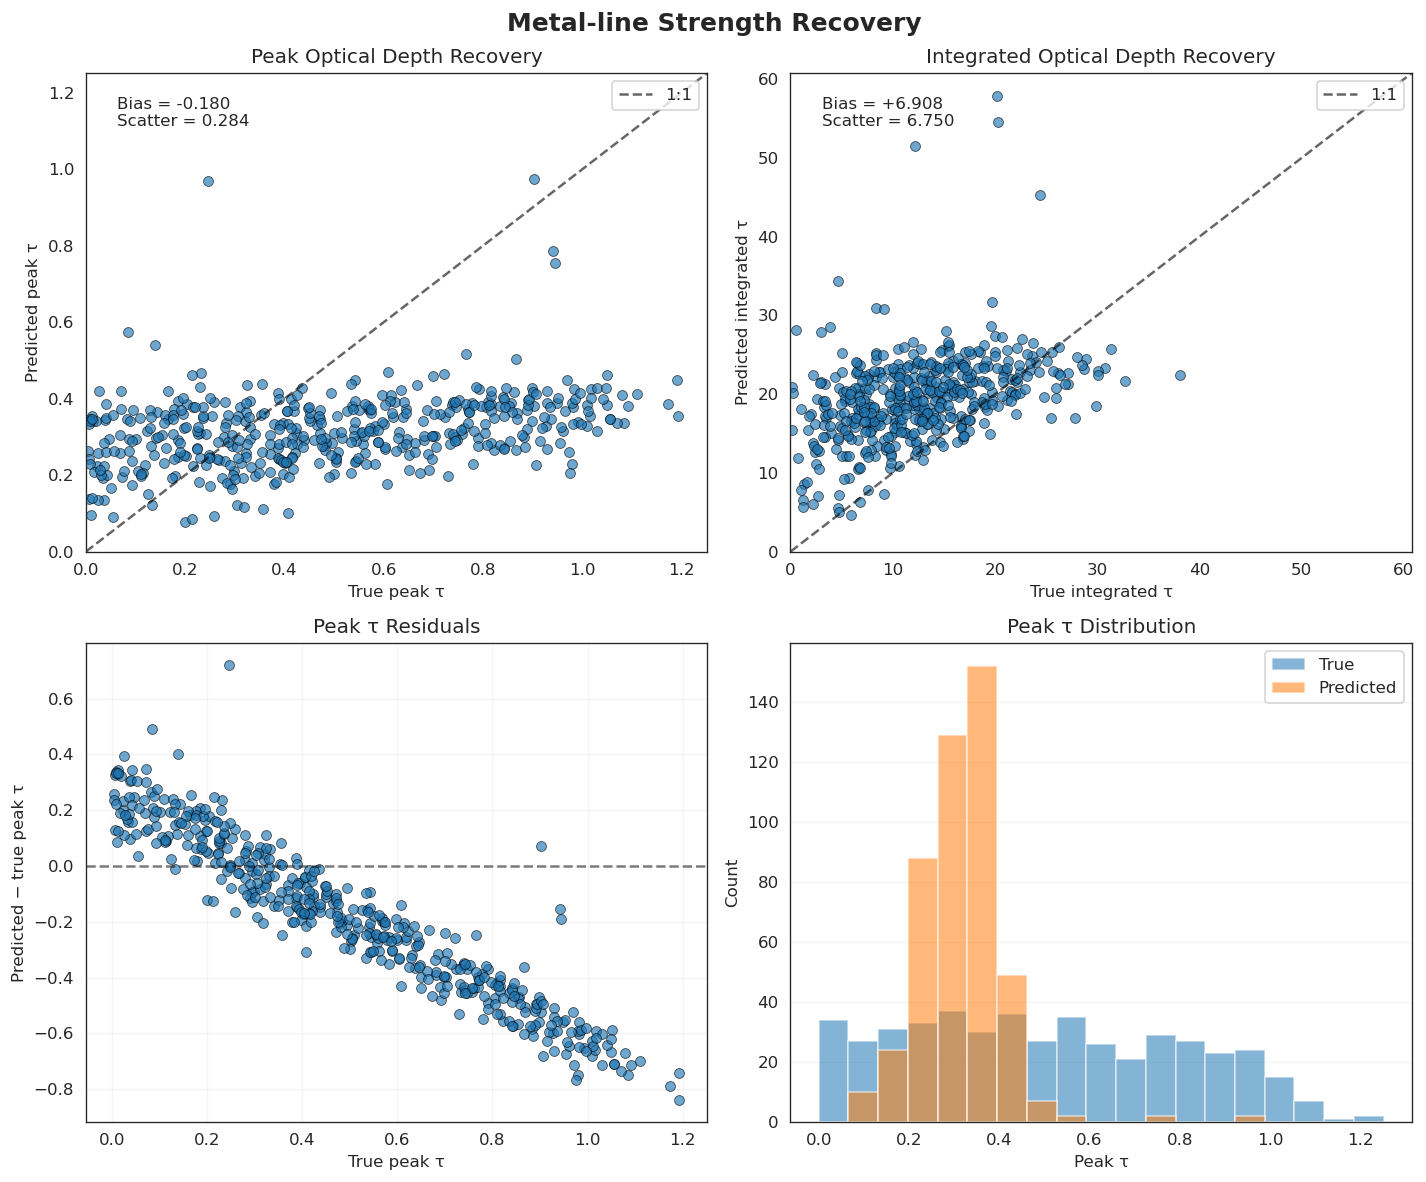

{'matched': [({'metal_name': 'MgI(2853)',
    'pixel': 197,
    'rest_wavelength_A': 2852.96,
    'z_absorber': 1.9767496311731252,
    'peak_tau': 0.16593113541603088,
    'integrated_tau': 3.001549510141726,
    'measured_width_pixels': 2.0,
    'measured_width_angstrom': 19.218588991592625,
    'measured_width_kms': 2020.910457026312,
    'snr': 1659.3113541603088,
    'prominence': 0.1657221560308244,
    'noise_level': 0.0001},
   {'metal_name': 'MgI(2853)',
    'pixel': 201,
    'rest_wavelength_A': 2852.96,
    'z_absorber': 2.033732092213858,
    'detect_prob': 0.7701836228370667,
    'peak_tau': 0.42066505551338196,
    'integrated_tau': 27.84574059382664}),
  ({'metal_name': 'MgI(2853)',
    'pixel': 199,
    'rest_wavelength_A': 2852.96,
    'z_absorber': 2.0036316955477704,
    'peak_tau': 0.13314694166183472,
    'integrated_tau': 2.700745635351129,
    'measured_width_pixels': 2.0,
    'measured_width_angstrom': 19.218588991592625,
    'measured_width_kms': 2020.910457026

In [104]:
plot_strength_diagnostics(
    model,
    samples,
    device="cpu",
    prob_threshold=0.5,
    distance=3,
    tol_pix=3,
    max_samples=None,
)